In [1]:
from THM_main import Version5_THM_prototype
from iapws import IAPWS97
import numpy as np
from THM_main import plotting
import pandas as pd
import matplotlib.pyplot as plt
import os
import re
# Begining of the script used to test the THM prototype class.

In [2]:
case_name = "MPHYS AT10"
#User choice:
solveConduction = True
plot_at_z1 = []

########## Thermal hydraulics parameters ##########
## Geometric parameters
#User choice:
solveConduction = True
zPlotting = []

If = 8
I1 = 3
# Sensitivity to the meshing parameters
Iz1 = 75 # number of control volumes in the axial direction, added 70 for comparison with GeN-Foam
# Iz1 = 10, 20, 40, 50, 70, 80 and 160 are supported for the DONJON solution


########## Choice of Thermalhydraulics correlation ##########
voidFractionCorrel = 'EPRIvoidCorrel' # 'modBestion', 'HEM1', 'GEramp', 'EPRIvoidModel'
frfaccorel = "Churchill" # 'base', 'blasius', 'Churchill', 'Churchill_notOK' ?
P2Pcorel = "lockhartMartinelli" # 'base', 'HEM1', 'HEM2', 'MNmodel', "lockhartMartinelli"
numericalMethod = "FVM" # "FVM": Solves the system using matrix inversion with preconditioning.
                        # "GaussSiedel" : Applies the Gauss-Seidel iterative solver.
                        # "BiCG" : Uses the BiConjugate Gradient method for solving non-symmetric or indefinite matrices.
                        # "BiCGStab" : Applies the BiCGStab (BiConjugate Gradient Stabilized) method to ensure faster and more stable convergence.

########## Thermal hydraulics parameters ##########
## Geometric parameters
canalType = "square" # "square", "cylindrical"
pitch =1.295e-2 #1.295e-2 # m : ATRIUM10 pincell pitch   0.0126 #
fuelRadius = 0.4435e-2 # m : fuel rod radius
#gapRadius = fuelRadius + 0.000001 # m : expansion gap radius : "void" between fuel and clad - equivalent to inner clad radius
gapRadius = 0.4520e-2 # m : expansion gap radius : "void" between fuel and clad - equivalent to inner clad radius
cladRadius = 0.5140e-2 # m : clad external radius
height = 1.655 # m : height : 3.8 m : active core height in BWRX-300 SMR, 1.555 m : for GF comparison.


## Fluid parameters
# T_inlet, T_outlet = 270, 287 Celcius
#tInlet = 270 + 273.15 # K, for BWRX-300 SMR core, try lowering the inlet temperature to set boiling point back and reduce the void fraction increase in the first few cm
tInlet = 270 + 273.15 # K, for BWRX-300 SMR core
#Nominal operating pressure = 7.2 MPa (abs)
pOutlet =  7.2e6 # Pa 
# Nominal coolant flow rate = 1530 kg/s
massFlowRate = 8.407 * 10**(-2) #1530  / (200*91)  # kg/s

## Material parameters
kFuel = 4.18 # W/m.K, TECHNICAL REPORTS SERIES No. 59 : Thermal Conductivity of Uranium Dioxide, IAEA, VIENNA, 1966
Hgap = 10000 
#Hgap = 9000
kClad = 21.5 # W/m.K, Thermal Conductivity of Zircaloy-2 (as used in BWRX-300) according to https://www.matweb.com/search/datasheet.aspx?MatGUID=eb1dad5ce1ad4a1f9e92f86d5b44740d
# k_Zircaloy-4 = 21.6 W/m.K too so check for ATRIUM-10 clad material but should have the same thermal conductivity

############ Nuclear Parameters ###########
# Number of fuel rods and assemblies for a small modular Boiling Water Reactor core

def main():
    qFiss = 400000000
    qFiss_init_4 = [0,0,0,0,0]
    for i in range(Iz1-5):
        qFiss_init_4.append(qFiss)

    case4 = Version5_THM_prototype("Initialization of BWR Pincell equivalent canal", canalType, pitch, fuelRadius, gapRadius, cladRadius, 
                            height, tInlet, pOutlet, massFlowRate, qFiss_init_4, kFuel, Hgap, kClad, Iz1, If, I1, zPlotting, 
                            solveConduction, dt = 0, t_tot = 0, frfaccorel = frfaccorel, P2Pcorel = P2Pcorel, voidFractionCorrel = 'EPRIvoidModel',
                            numericalMethod = numericalMethod)
    

    qFiss = 200000000
    qFiss_init_2 = [0,0,0,0,0]
    for i in range(Iz1-5):
        qFiss_init_2.append(qFiss)
        
    case2 = Version5_THM_prototype("Initialization of BWR Pincell equivalent canal", canalType, pitch, fuelRadius, gapRadius, cladRadius, 
                            height, tInlet, pOutlet, massFlowRate, qFiss_init_2, kFuel, Hgap, kClad, Iz1, If, I1, zPlotting, 
                            solveConduction, dt = 0, t_tot = 0, frfaccorel = frfaccorel, P2Pcorel = P2Pcorel, voidFractionCorrel = 'EPRIvoidModel',
                            numericalMethod = numericalMethod)

    qFiss = 100000000
    qFiss_init_1 = [0,0,0,0,0]
    for i in range(Iz1-5):
        qFiss_init_1.append(qFiss)
    
    case1 = Version5_THM_prototype("Initialization of BWR Pincell equivalent canal", canalType, pitch, fuelRadius, gapRadius, cladRadius, 
                            height, tInlet, pOutlet, massFlowRate, qFiss_init_1, kFuel, Hgap, kClad, Iz1, If, I1, zPlotting, 
                            solveConduction, dt = 0, t_tot = 0, frfaccorel = frfaccorel, P2Pcorel = P2Pcorel, voidFractionCorrel = 'EPRIvoidModel',
                            numericalMethod = numericalMethod)
    
    qFiss = 40000000
    qFiss_init_0 = [0,0,0,0,0]
    for i in range(Iz1-5):
        qFiss_init_0.append(qFiss)
    
    caseMono = Version5_THM_prototype("Initialization of BWR Pincell equivalent canal", canalType, pitch, fuelRadius, gapRadius, cladRadius, 
                            height, tInlet, pOutlet, massFlowRate, qFiss_init_0, kFuel, Hgap, kClad, Iz1, If, I1, zPlotting, 
                            solveConduction, dt = 0, t_tot = 0, frfaccorel = frfaccorel, P2Pcorel = P2Pcorel, voidFractionCorrel = 'EPRIvoidModel',
                            numericalMethod = numericalMethod)
    
    caseMerge = [case4, case2, case1, caseMono]#, case1, case2, case3, case4, case5, case6, case7, case8]
    return caseMerge

caseMerge = main()
#if __name__ == "__main__":
#    cProfile.run('main()', filename='profiling_result.prof')

print(f"len(caseMerge[0].convection.sol.T_water) = {len(caseMerge[0].convection_sol.T_water)}")


$$$---------- THM: prototype, case treated : Initialization of BWR Pincell equivalent canal.
$$$---------- THM: prototype, steady state case.
$$---------- Calling DFM class.
Setting up heat convection solution along the axial dimension. zmax = 1.655 m with 75 axial elements.
self.I_z: 75
self.qFlow: 0.08407
self.pOutlet: 7200000.0
self.Lf: 1.655
self.r_f: 0.004435
self.clad_r: 0.00514
self.r_w: 0.01295
self.Dz: 0.02206666666666667
self.dt: 0
Courant number: 0.0
Numerical Method FVM
Velocity at the inlet:  1.2884090506886694
Dh: 0.010490958633360763
Hydraulic diameter: [0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.0104

c:\Users\cleme\OneDrive\Documents\Poly\BWR\THM_prototype\THM_waterProp.py:561: RuntimeWarning: divide by zero encountered in scalar divide
  return self.U[i] - (self.voidFractionTEMP[i] / ( 1 - self.voidFractionTEMP[i])) * (self.rhogTEMP[i] / self.rhoTEMP[i]) * self.VgjPrimeTEMP[i]
c:\Users\cleme\OneDrive\Documents\Poly\BWR\THM_prototype\THM_waterProp.py:576: RuntimeWarning: invalid value encountered in sqrt
  return 1 + 1/np.sqrt(X) + 20/X


Convergence test, residuals: epsilon: 3.579008981117465, rho: 8.15391100919924, xTh: 7.912836039181782
uInlet:1.2891115505816395
uInlet:1.2890983212588607
Convergence test, residuals: epsilon: 0.11847063305818938, rho: 0.2870144506204607, xTh: 0.0012197910346069137
uInlet:1.2890983212588607
uInlet:1.2890725074136924
Convergence test, residuals: epsilon: 0.012845844326237421, rho: 0.015169651263545329, xTh: 0.001560821831275782
uInlet:1.2890725074136924
uInlet:1.2890705474289568
Convergence test, residuals: epsilon: 0.0005633753869420026, rho: 0.0010506077410913398, xTh: 0.00036304903094043966
uInlet:1.2890705474289568
uInlet:1.2890705164383782
Convergence test, residuals: epsilon: 4.6823938701823515e-05, rho: 0.00010369681817050298, xTh: 3.009175382658285e-05
uInlet:1.2890705164383782
Convergence reached at iteration number: 4
Pressure: [7231320.088836917, 7231218.166079323, 7231116.2431584075, 7231014.320074165, 7230912.396826604, 7230810.473415725, 7230708.549841525, 7230606.62610400

In [3]:

class GFPlotter():
    def __init__(self, caseList, directory_path, case_name, second_path = ""):
        self.case_name = f'{case_name}\\'

        self.caseList = caseList
        self.directory_path = directory_path
        self.height = self.caseList[0].convection_sol.height

        self.data_dict_list = []
        self.data_dict = self.read_files_in_directory()
        self.allow_space()

        self.struture_fraction = 1 - (self.alpha_liquid[0] + self.alpha_vapour[0])

        self.calculateFields()
        self.createZ()

    def plotCase(self):
        title = f"f: {self.caseList[0].convection_sol.frfaccorel}, \n Méthode numérique: {self.caseList[0].convection_sol.numericalMethod}, \n Correlation void fraction: {self.caseList[0].convection_sol.voidFractionCorrel}"
        labelTitle = 'THM_prototype'
        fig1, ax1 = plt.subplots()
        for i in range(len(self.caseList)):
            ax1.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.T_water, label=labelTitle)
        ax1.set_xlabel("Axial position in m")
        ax1.set_ylabel("Temperature in K")
        ax1.set_title(f"{title}")
        ax1.grid()
        ax1.legend(loc="best")
        fig1.savefig(rf'result\{self.case_name}\Tcoolant.png', bbox_inches='tight')

        fig2, ax2 = plt.subplots()
        for i in range(len(self.caseList)):
            ax2.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.voidFraction[-1], label=labelTitle)

        ax2.set_xlabel("Axial position in m")
        ax2.set_ylabel("Void fraction")
        ax2.set_title(f"{title}")
        ax2.grid()
        ax2.legend(loc="best")
        fig2.savefig(rf'result\{self.case_name}\epsilon.png', bbox_inches='tight')

        fig3, ax3 = plt.subplots()
        print(f"rho_mix GF: {self.rho_mixture}")
        for i in range(len(self.caseList)):
            ax3.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.rho[-1], label=labelTitle)

        ax3.set_xlabel("Axial position in m")
        ax3.set_ylabel("Density in kg/m^3")
        ax3.set_title(f"{title}")
        ax3.grid()
        ax3.legend(loc="best")
        fig3.savefig(rf'result\{self.case_name}\Rho.png', bbox_inches='tight')

        fig7, ax7 = plt.subplots()
        for i in range(len(self.caseList)):
            ax7.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.rhoL[-1], label=labelTitle)
        ax7.set_xlabel("Axial position in m")
        ax7.set_ylabel("Liquid density in kg/m^3")
        ax7.set_title(f"{title}")
        ax7.grid()
        ax7.legend(loc="best")
        fig7.savefig(rf'result\{self.case_name}\RhoL.png', bbox_inches='tight')

        fig8, ax8 = plt.subplots()
        for i in range(len(self.caseList)):
            ax8.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.rhoG[-1], label=labelTitle)
        ax8.set_xlabel("Axial position in m")
        ax8.set_ylabel("Vapour density in kg/m^3")
        ax8.set_title(f"{title}")
        ax8.grid()
        ax8.legend(loc="best")
        fig8.savefig(rf'result\{self.case_name}\RhoG.png', bbox_inches='tight')

        fig4, ax4 = plt.subplots() 
        for i in range(len(self.caseList)):
            labelTitle = f"THM_prototype {self.caseList[i].convection_sol.frfaccorel}"
            ax4.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.P[-1], label=labelTitle)
        ax4.step(self.zList, self.p_rgh, label="GF P_rgh")
        ax4.set_xlabel("Axial position in m")
        ax4.set_ylabel("Pressure in Pa")
        ax4.grid()
        ax4.set_title(f"{title}")
        ax4.legend(loc="best")
        fig4.savefig(rf'result\{self.case_name}\P.png', bbox_inches='tight')

        fig5, ax5 = plt.subplots()
        for i in range(len(self.caseList)):
            ax5.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.Ul, label=labelTitle)
        ax5.set_xlabel("Axial position in m")
        ax5.set_ylabel("Liquid Velocity in m/s")
        ax5.set_title(f"{title}")
        ax5.grid()
        ax5.legend(loc="best")
        fig5.savefig(rf'result\{self.case_name}\Ul.png', bbox_inches='tight')

        fig6, ax6 = plt.subplots()
        for i in range(len(self.caseList)):
            ax6.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.Ug, label=labelTitle)
        ax6.set_xlabel("Axial position in m")
        ax6.set_ylabel("Vapour Velocity in m/s")
        ax6.set_title(f"{title}")
        ax6.grid()
        ax6.legend(loc="best")
        fig6.savefig(rf'result\{self.case_name}\Ug.png', bbox_inches='tight')

        fig9, ax9 = plt.subplots()
        for i in range(len(self.caseList)):
            ax9.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.U[-1], label=labelTitle)
        ax9.set_xlabel("Axial position in m")
        ax9.set_ylabel("Mixture Velocity in m/s")
        ax9.set_title(f"{title}")
        ax9.grid()
        ax9.legend(loc="best")
        fig9.savefig(rf'result\{self.case_name}\U.png', bbox_inches='tight')

        fig10, ax10 = plt.subplots()
        for i in range(len(self.caseList)):
            ax10.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.Rel, label=labelTitle)
        ax10.set_xlabel("Axial position in m")
        ax10.set_ylabel("Reynolds number")
        ax10.set_title(f"{title}")
        ax10.grid()
        ax10.legend(loc="best")
        fig10.savefig(rf'result\{self.case_name}\Re.png', bbox_inches='tight')

        fig11, ax11 = plt.subplots()
        ax11.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.xTh[-1], label=labelTitle)
        ax11.set_xlabel("Axial position in m")
        ax11.set_ylabel("xTh")
        ax11.set_title(f"{title}")
        ax11.grid()
        ax11.legend(loc="best")
        fig11.savefig(rf'result\{self.case_name}\xTh.png', bbox_inches='tight')

        
        fig12, ax12 = plt.subplots()
        for i in range(len(self.caseList)):
            rhoUA_liquid = [self.caseList[i].convection_sol.Ul[j] * self.caseList[i].convection_sol.rhoL[-1][j]*self.caseList[i].convection_sol.areaMatrix[j] for j in range(len(self.caseList[i].convection_sol.Ul))]
            ax12.step(self.caseList[i].convection_sol.z_mesh, rhoUA_liquid, label=labelTitle + " rhoUA_liquid")
        #ax12.step(self.zList, self.alphaRhoMagU_liquid, label="GF")
        ax12.set_xlabel("Axial position in m")
        ax12.set_ylabel("rhoUA_liquid")
        ax12.set_title(f"{title}")
        ax12.grid()
        fig12.savefig(rf'result\{self.case_name}\rhoUA_liquid.png', bbox_inches='tight')

        fig13, ax13 = plt.subplots()
        for i in range(len(self.caseList)):
            rhoUA_vapour = [self.caseList[i].convection_sol.Ug[j] * self.caseList[i].convection_sol.rhoG[-1][j]*self.caseList[i].convection_sol.areaMatrix[j] for j in range(len(self.caseList[i].convection_sol.Ug))]
            ax13.step(self.caseList[i].convection_sol.z_mesh, rhoUA_vapour, label=labelTitle + " rhoUA_vapour")
        #ax13.step(self.zList, self.alphaRhoMagU_vapour, label="GF")
        ax13.set_xlabel("Axial position in m")
        ax13.set_ylabel("rhoUA_vapour")
        ax13.set_title(f"{title}")
        ax13.grid()
        fig13.savefig(rf'result\{self.case_name}\rhoUA_vapour.png', bbox_inches='tight')

        fig14, ax14 = plt.subplots()
        for i in range(len(self.caseList)):
            self.rhoUA = [self.caseList[i].convection_sol.U[-1][j] * self.caseList[i].convection_sol.rho[-1][j]*self.caseList[i].convection_sol.areaMatrix[j] for j in range(len(self.caseList[i].convection_sol.Ug))]
            ax14.step(self.caseList[i].convection_sol.z_mesh, self.rhoUA, label=labelTitle + " rhoUA")
        #ax14.step(self.zList, self.alphaRhoMagU_liquid, label="GF")
        ax14.set_xlabel("Axial position in m")
        ax14.set_ylabel("rhoUA")
        ax14.set_title(f"{title}")
        ax14.grid()
        fig14.savefig(rf'result\{self.case_name}\rhoUA.png', bbox_inches='tight')
        

        plt.show()

    def createZ(self):
        self.zList = np.linspace(0, self.height, len(self.alpha_liquid))

    def read_files_in_directory(self):
        data_dict = {}
        print(f"Reading files in directory: {self.directory_path}")
        # Parcourt tous les fichiers du dossier
        for filename in os.listdir(self.directory_path):
            file_path = os.path.join(self.directory_path, filename)
            print(f"Reading file: {file_path}")
            # Vérifie que c'est bien un fichier
            if os.path.isfile(file_path):

                with open(file_path, 'r') as file:
                    content = file.read()
                    
                    # Trouve la première parenthèse ouvrante et fermante
                    start = content.find('(')
                    end = content.find(')', start)
                    #end = start + 74
                    if start != -1 and end != -1:
                        # Extrait les données entre les parenthèses
                        data_str = content[start+1:end].strip()
                        # Divise les lignes en liste de chaînes
                        data_lines = data_str.splitlines()
                        if len(data_lines) != 1:
                            float_list = [float(item) for item in data_lines]
                            data_dict[filename] = float_list

                    if len(data_lines) == 1:
                        # Trouve la première parenthèse ouvrante et fermante
                        start = content.find('(')
                        end = content.find(';', start)
                        #end = start
                        if start != -1 and end != -1:
                            # Extrait les données entre les parenthèses
                            data_str = content[start+1:end].strip()
                            # Divise les lignes en liste de chaînes
                            data_lines = data_str.splitlines()
                            data_lines.pop()
                            x, y, z = np.zeros(len(data_lines)), np.zeros(len(data_lines)), np.zeros(len(data_lines))
                            for i in range(len(data_lines)):
                                a = values = data_lines[i].strip("()").split()
                                x[i] = float(a[0])
                                y[i] = float(a[1])
                                z[i] = float(a[2])
                            data_dict[fr'{filename}_x'] = x
                            data_dict[fr'{filename}_y'] = y
                            data_dict[fr'{filename}_z'] = z
        
        return data_dict
    
    def allow_space(self):
        self.alpha_liquid = np.array(self.data_dict['alpha.liquid'])
        self.alpha_vapour = np.array(self.data_dict['alpha.vapour'])
        #self.alpha_powerModel = np.array(self.data_dict['alpha.powerModel'])
        self.alphaPhi_liquid = np.array(self.data_dict['alphaPhi.liquid']+ [self.data_dict['alphaPhi.liquid'][-1]])
        self.alphaPhi_vapour = np.array(self.data_dict['alphaPhi.vapour']+ [self.data_dict['alphaPhi.vapour'][-1]])
        self.alphaRhoMagU_liquid = np.array(self.data_dict['alphaRhoMagU.liquid'])#+ [self.data_dict['alphaRhoMagU.liquid'][-1]])
        self.alphaRhoMagU_vapour = np.array(self.data_dict['alphaRhoMagU.vapour'])#+ [self.data_dict['alphaRhoMagU.vapour'][-1]])
        self.alphaRhoPhi_liquid = np.array(self.data_dict['alphaRhoPhi.liquid']+ [self.data_dict['alphaRhoPhi.liquid'][-1]])
        self.alphaRhoPhi_vapour = np.array(self.data_dict['alphaRhoPhi.vapour']+ [self.data_dict['alphaRhoPhi.vapour'][-1]])
        self.areaDensity_interface = np.array(self.data_dict['areaDensity.interface'])
        self.dgdt_liquid = np.array(self.data_dict['dgdt.liquid'])
        self.dgdt_vapour = np.array(self.data_dict['dgdt.vapour'])
        self.dmdt_vapour = np.array(self.data_dict['dmdt.liquid.vapour'])
        self.heatFlux_structure = np.array(self.data_dict['heatFlux.structure'])
        self.htc_liquid_interface = np.array(self.data_dict['htc.liquid.interface'])
        self.htc_liquid_structure = np.array(self.data_dict['htc.liquid.structure'])
        self.p = np.array(self.data_dict['p'])
        self.p_rgh = np.array(self.data_dict['p_rgh'])
        self.Re_liquid_structure = np.array(self.data_dict['Re.liquid.structure'])
        #self.Re_vapour_structure = np.array(self.data_dict['Re.vapour.structure'])
        self.Re_liquid_vapour = np.array(self.data_dict['Re.liquid.vapour'])
        self.T_fixedPower = np.array(self.data_dict['T.fixedPower'])
        self.T_liquid = np.array(self.data_dict['T.liquid'])
        self.T_vapour = np.array(self.data_dict['T.vapour'])
        self.U_liquid_x = np.array(self.data_dict['U.liquid_x'])
        self.U_liquid_y = np.array(self.data_dict['U.liquid_y'])
        self.U_liquid_z = np.array(self.data_dict['U.liquid_z'])
        self.U_vapour_x = np.array(self.data_dict['U.vapour_x'])
        self.U_vapour_y = np.array(self.data_dict['U.vapour_y'])
        self.U_vapour_z = np.array(self.data_dict['U.vapour_z'])

    def calculateFields(self):
        self.alpha_vapour = self.alpha_vapour/(1-self.struture_fraction)
        self.alpha_liquid = self.alpha_liquid/(1-self.struture_fraction)
        self.U_liquid = np.sqrt(self.U_liquid_x**2 + self.U_liquid_y**2 + self.U_liquid_z**2)
        self.U_vapour = np.sqrt(self.U_vapour_x**2 + self.U_vapour_y**2 + self.U_vapour_z**2)
        self.U_mixture = (1-self.alpha_vapour) * self.U_liquid + self.alpha_vapour * self.U_vapour

        self.rho_liquid  = self.alphaRhoPhi_liquid/(self.alphaPhi_liquid)
        self.rho_vapour = self.alphaRhoPhi_vapour/(self.alphaPhi_vapour)
        for i in range(len(self.rho_vapour)):
            if np.isnan(self.rho_vapour[i]):
                self.rho_vapour[i] = 0
            if np.isnan(self.rho_liquid[i]):
                self.rho_liquid[i] = 0
        print(f"rho_liquid GeN-Foam: {self.rho_liquid}")
        print(f"rho_vapour GeN-Foam: {self.rho_vapour}")
        self.rho_mixture = self.rho_liquid + self.rho_vapour

        self.T_mixture = (1-self.alpha_vapour) * self.T_liquid + self.alpha_vapour * self.T_vapour

    def plotComparison(self):
        file_path = rf'C:\Users\cleme\OneDrive\Documents\Poly\BWR\THM_prototype\result\{self.case_name}'
        os.makedirs(os.path.dirname(file_path), exist_ok=True)
        if len(self.caseList) == 1:
            labelTitle = 'THM_prototype'
        labelTitle = 'THM_prototype'
        title = ""#f"f: {self.caseList[0].convection_sol.frfaccorel}, \n Méthode numérique: {self.caseList[0].convection_sol.numericalMethod}, \n Correlation void fraction: {self.caseList[0].convection_sol.voidFractionCorrel}"
        
        fig0, ax0 = plt.subplots()
        for i in range(len(self.caseList)):
            ax0.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.xTh[-1], label=labelTitle)
        ax0.set_xlabel("Axial position in m")
        ax0.set_ylabel("Quality")
        ax0.set_title(f"{title}")
        ax0.grid()
        ax0.legend(loc="best")
        fig0.savefig(rf'result\{self.case_name}\xTh.png', bbox_inches='tight')

        fig1, ax1 = plt.subplots()
        for i in range(len(self.caseList)):
            ax1.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.T_water, label=labelTitle)
        #ax1.step(self.zList, self.T_liquid, label="GF T.liquid")
        #ax1.step(self.zList, self.T_vapour, label="GF T.vapour")
        ax1.step(self.zList, self.T_mixture, label="GF")
        ax1.set_xlabel("Axial position in m")
        ax1.set_ylabel("Temperature in K")
        ax1.set_title(f"{title}")
        ax1.grid()
        ax1.legend(loc="best")
        fig1.savefig(rf'result\{self.case_name}\Tcoolant.png', bbox_inches='tight')

        fig2, ax2 = plt.subplots()
        for i in range(len(self.caseList)):
            ax2.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.voidFraction[-1], label=labelTitle)
        ax2.step(self.zList, self.alpha_vapour, label="GF")
        ax2.set_xlabel("Axial position in m")
        ax2.set_ylabel("Void fraction")
        ax2.set_title(f"{title}")
        ax2.grid()
        ax2.legend(loc="best")
        fig2.savefig(rf'result\{self.case_name}\epsilon.png', bbox_inches='tight')

        fig3, ax3 = plt.subplots()
        print(f"rho_mix GeN-Foam: {self.rho_mixture}")
        for i in range(len(self.caseList)):
            ax3.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.rho[-1], label=labelTitle)
        ax3.plot(self.zList, self.rho_mixture, label="GF")
        ax3.set_xlabel("Axial position in m")
        ax3.set_ylabel("Density in kg/m^3")
        ax3.set_title(f"{title}")
        ax3.grid()
        ax3.legend(loc="best")
        fig3.savefig(rf'result\{self.case_name}\Rho.png', bbox_inches='tight')

        fig7, ax7 = plt.subplots()
        for i in range(len(self.caseList)):
            ax7.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.rhoL[-1], label=labelTitle)
        ax7.plot(self.zList, self.rho_liquid, label="GF")
        ax7.set_xlabel("Axial position in m")
        ax7.set_ylabel("Liquid density in kg/m^3")
        ax7.set_title(f"{title}")
        ax7.grid()
        ax7.legend(loc="best")
        fig7.savefig(rf'result\{self.case_name}\RhoL.png', bbox_inches='tight')

        fig8, ax8 = plt.subplots()
        for i in range(len(self.caseList)):
            ax8.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.rhoG[-1], label=labelTitle)
        ax8.plot(self.zList, self.rho_vapour, label="GF")
        ax8.set_xlabel("Axial position in m")
        ax8.set_ylabel("Vapour density in kg/m^3")
        ax8.set_title(f"{title}")
        ax8.grid()
        ax8.legend(loc="best")
        fig8.savefig(rf'result\{self.case_name}\RhoG.png', bbox_inches='tight')

        fig4, ax4 = plt.subplots() 
        for i in range(len(self.caseList)):
            labelTitle = f"THM_prototype {self.caseList[i].convection_sol.frfaccorel} {self.caseList[i].convection_sol.P2Pcorel}"
            ax4.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.P[-1], label=labelTitle)
        ax4.step(self.zList, self.p, label="GF")
        ax4.step(self.zList, self.p_rgh, label="GF P_rgh")
        ax4.set_xlabel("Axial position in m")
        ax4.set_ylabel("Pressure in Pa")
        ax4.grid()
        ax4.set_title(f"{title}")
        ax4.legend(loc="best")
        fig4.savefig(rf'result\{self.case_name}\P.png', bbox_inches='tight')

        fig5, ax5 = plt.subplots()
        for i in range(len(self.caseList)):
            ax5.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.Ul, label=labelTitle)
        ax5.step(self.zList, self.U_liquid, label="GF")
        ax5.set_xlabel("Axial position in m")
        ax5.set_ylabel("Liquid Velocity in m/s")
        ax5.set_title(f"{title}")
        ax5.grid()
        ax5.legend(loc="best")
        fig5.savefig(rf'result\{self.case_name}\Ul.png', bbox_inches='tight')

        fig6, ax6 = plt.subplots()
        for i in range(len(self.caseList)):
            ax6.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.Ug, label=labelTitle)
        ax6.step(self.zList, self.U_vapour, label="GF")
        ax6.set_xlabel("Axial position in m")
        ax6.set_ylabel("Vapour Velocity in m/s")
        ax6.set_title(f"{title}")
        ax6.grid()
        ax6.legend(loc="best")
        fig6.savefig(rf'result\{self.case_name}\Ug.png', bbox_inches='tight')

        fig9, ax9 = plt.subplots()
        for i in range(len(self.caseList)):
            ax9.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.U[-1], label=labelTitle)
        ax9.step(self.zList, self.U_mixture, label="GF")
        ax9.set_xlabel("Axial position in m")
        ax9.set_ylabel("Mixture Velocity in m/s")
        ax9.set_title(f"{title}")
        ax9.grid()
        ax9.legend(loc="best")
        fig9.savefig(rf'result\{self.case_name}\U.png', bbox_inches='tight')

        fig10, ax10 = plt.subplots()
        for i in range(len(self.caseList)):
            ax10.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.Rel, label=labelTitle)
        ax10.step(self.zList, self.Re_liquid_structure, label="GF")
        ax10.set_xlabel("Axial position in m")
        ax10.set_ylabel("Reynolds number")
        ax10.set_title(f"{title}")
        ax10.grid()
        ax10.legend(loc="best")
        fig10.savefig(rf'result\{self.case_name}\Re.png', bbox_inches='tight')

        fig11, ax11 = plt.subplots()
        ax11.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.xTh[-1], label=labelTitle)
        ax11.set_xlabel("Axial position in m")
        ax11.set_ylabel("xTh")
        ax11.set_title(f"{title}")
        ax11.grid()
        ax11.legend(loc="best")
        fig11.savefig(rf'result\{self.case_name}\xTh.png', bbox_inches='tight')

        
        fig12, ax12 = plt.subplots()
        for i in range(len(self.caseList)):
            rhoUA_liquid = [self.caseList[i].convection_sol.Ul[j] * self.caseList[i].convection_sol.rhoL[-1][j]*self.caseList[i].convection_sol.areaMatrix[j] for j in range(len(self.caseList[i].convection_sol.Ul))]
            ax12.step(self.caseList[i].convection_sol.z_mesh, rhoUA_liquid, label=labelTitle + " rhoUA_liquid")
        #ax12.step(self.zList, self.alphaRhoMagU_liquid, label="GF")
        ax12.set_xlabel("Axial position in m")
        ax12.set_ylabel("rhoUA_liquid")
        ax12.set_title(f"{title}")
        ax12.grid()
        fig12.savefig(rf'result\{self.case_name}\rhoUA_liquid.png', bbox_inches='tight')

        fig13, ax13 = plt.subplots()
        for i in range(len(self.caseList)):
            rhoUA_vapour = [self.caseList[i].convection_sol.Ug[j] * self.caseList[i].convection_sol.rhoG[-1][j]*self.caseList[i].convection_sol.areaMatrix[j] for j in range(len(self.caseList[i].convection_sol.Ug))]
            ax13.step(self.caseList[i].convection_sol.z_mesh, rhoUA_vapour, label=labelTitle + " rhoUA_vapour")
        #ax13.step(self.zList, self.alphaRhoMagU_vapour, label="GF")
        ax13.set_xlabel("Axial position in m")
        ax13.set_ylabel("rhoUA_vapour")
        ax13.set_title(f"{title}")
        ax13.grid()
        fig13.savefig(rf'result\{self.case_name}\rhoUA_vapour.png', bbox_inches='tight')

        fig14, ax14 = plt.subplots()
        for i in range(len(self.caseList)):
            self.rhoUA = [self.caseList[i].convection_sol.U[-1][j] * self.caseList[i].convection_sol.rho[-1][j]*self.caseList[i].convection_sol.areaMatrix[j] for j in range(len(self.caseList[i].convection_sol.Ug))]
            ax14.step(self.caseList[i].convection_sol.z_mesh, self.rhoUA, label=labelTitle + " rhoUA")
        #ax14.step(self.zList, self.alphaRhoMagU_liquid, label="GF")
        ax14.set_xlabel("Axial position in m")
        ax14.set_ylabel("rhoUA")
        ax14.set_title(f"{title}")
        ax14.grid()
        fig14.savefig(rf'result\{self.case_name}\rhoUA.png', bbox_inches='tight')
        

        plt.show()

    def computeErrors(self):
        self.error_T_abs = []
        self.error_T_rel = []
        self.error_p_abs = []
        self.error_p_rel = []
        self.error_rho_abs = []
        self.error_rho_rel = []
        self.error_U_abs = []
        self.error_U_rel = []
        self.error_Re_abs = []
        self.error_Re_rel = []
        self.error_eps_abs = []
        self.error_eps_rel = []

        for i in range(len(self.caseList)):
            self.error_T_abs.append((self.T_mixture - self.caseList[i].convection_sol.T_water))
            self.error_T_rel.append(100*self.error_T_abs[-1]/(self.T_mixture))
            self.error_p_abs.append((self.p - self.caseList[i].convection_sol.P[-1]))
            self.error_p_rel.append(100*self.error_p_abs[-1]/(self.p))
            self.error_rho_abs.append(self.rho_mixture - self.caseList[i].convection_sol.rho[-1])
            self.error_rho_rel.append(100*self.error_rho_abs[-1]/(self.rho_mixture))
            self.error_U_abs.append((self.U_mixture - self.caseList[i].convection_sol.U[-1]))
            self.error_U_rel.append(100*self.error_U_abs[-1]/(self.U_mixture))
            self.error_Re_abs.append((self.Re_liquid_structure - self.caseList[i].convection_sol.Rel))
            self.error_Re_rel.append(100*self.error_Re_abs[-1]/(self.Re_liquid_structure))
            self.error_eps_abs.append((self.alpha_vapour - self.caseList[i].convection_sol.voidFraction[-1]))
            self.error_eps_rel.append(self.error_eps_abs[-1]/(self.alpha_vapour))

            

    def plotErrorsPressure(self):
        fig, ax = plt.subplots()
        for i in range(len(self.caseList)):
            print(self.error_p_abs)
            ax.step(self.caseList[i].convection_sol.z_mesh, self.error_p_abs[i], label=f" {self.caseList[i].convection_sol.frfaccorel} , {self.caseList[i].convection_sol.P2Pcorel}")
        ax.set_xlabel("Axial position in m")
        ax.set_ylabel("Absolute error in Pa")
        ax.set_title("Absolute error in pressure")
        ax.grid()
        ax.legend(loc="best")
        fig.savefig(rf'result\{self.case_name}\error_p_abs.png', bbox_inches='tight')

        fig1, ax1 = plt.subplots()
        for i in range(len(self.caseList)):
            ax1.step(self.caseList[i].convection_sol.z_mesh, self.error_p_rel[i], label=f" {self.caseList[i].convection_sol.frfaccorel} , {self.caseList[i].convection_sol.P2Pcorel}")
        ax1.set_xlabel("Axial position in m")
        ax1.set_ylabel("Relative error in %")
        ax1.set_title("Relative error in pressure")
        ax1.grid()
        ax1.legend(loc="best")
        fig1.savefig(rf'result\{self.case_name}\error_p_rel.png', bbox_inches='tight')

        plt.show()

        for i in range(len(self.caseList)):
            print(f"Mean relative error in pressure: {np.mean(self.error_p_rel[i])}, max relative error in pressure {np.max(self.error_p_rel[i])} for {self.caseList[i].convection_sol.frfaccorel}, {self.caseList[i].convection_sol.P2Pcorel}")


In [4]:

class GFPlotterComp(): #caseList, pathList, case_name, legendList
    def __init__(self, caseList, pathList, case_name, legendList, THM_list):
        self.case_name = f'{case_name}\\'

        self.caseList = caseList
        self.pathList = pathList
        #self.directory_path = directory_path
        self.height = self.caseList[0].convection_sol.height
        self.legendList = legendList

        self.data_dict_list = self.read_files_in_directory()
        self.allow_space()
        self.THM_list = THM_list
        self.struture_fraction = 1 - (self.alpha_liquid[0][0] + self.alpha_vapour[0][0])

        self.calculateFields()

        self.createZ()

    def createZ(self):
        self.zList = []
        for i in range(len(self.caseList)):
            self.zList.append(self.caseList[i].convection_sol.z_mesh)

    def read_files_in_directory(self):
        dataList = []
        for directory_path in self.pathList:
            data_dict = {}
            print(f"Reading files in directory: {directory_path}")
            # Parcourt tous les fichiers du dossier
            for filename in os.listdir(directory_path):
                file_path = os.path.join(directory_path, filename)
                print(f"Reading file: {file_path}")
                # Vérifie que c'est bien un fichier
                if os.path.isfile(file_path):

                    with open(file_path, 'r') as file:
                        content = file.read()
                        
                        # Trouve la première parenthèse ouvrante et fermante
                        start = content.find('(')
                        end = content.find(')', start)
                        #end = start + 74
                        if start != -1 and end != -1:
                            # Extrait les données entre les parenthèses
                            data_str = content[start+1:end].strip()
                            # Divise les lignes en liste de chaînes
                            data_lines = data_str.splitlines()
                            if len(data_lines) != 1:
                                float_list = [float(item) for item in data_lines]
                                data_dict[filename] = float_list

                        if len(data_lines) == 1:
                            # Trouve la première parenthèse ouvrante et fermante
                            start = content.find('(')
                            end = content.find(';', start)
                            #end = start
                            if start != -1 and end != -1:
                                # Extrait les données entre les parenthèses
                                data_str = content[start+1:end].strip()
                                # Divise les lignes en liste de chaînes
                                data_lines = data_str.splitlines()
                                data_lines.pop()
                                x, y, z = np.zeros(len(data_lines)), np.zeros(len(data_lines)), np.zeros(len(data_lines))
                                for i in range(len(data_lines)):
                                    a = values = data_lines[i].strip("()").split()
                                    x[i] = float(a[0])
                                    y[i] = float(a[1])
                                    z[i] = float(a[2])
                                data_dict[fr'{filename}_x'] = x
                                data_dict[fr'{filename}_y'] = y
                                data_dict[fr'{filename}_z'] = z
            dataList.append(data_dict)
            
        return dataList
    
    def allow_space(self):
        self.alpha_liquid = [np.array(self.data_dict_list[i]['alpha.liquid']) for i in range(len(self.data_dict_list))]
        self.alpha_vapour = [np.array(self.data_dict_list[i]['alpha.vapour']) for i in range(len(self.data_dict_list))]
        #self.alpha_powerModel = np.array(self.data_dict['alpha.powerModel'])
        self.alphaPhi_liquid = [np.array(self.data_dict_list[i]['alphaPhi.liquid']+ [self.data_dict_list[i]['alphaPhi.liquid'][-1]]) for i in range(len(self.data_dict_list))]
        self.alphaPhi_vapour = [np.array(self.data_dict_list[i]['alphaPhi.vapour']+ [self.data_dict_list[i]['alphaPhi.vapour'][-1]]) for i in range(len(self.data_dict_list))]
        self.alphaRhoMagU_liquid = [np.array(self.data_dict_list[i]['alphaRhoMagU.liquid']) for i in range(len(self.data_dict_list))]
        self.alphaRhoMagU_vapour = [np.array(self.data_dict_list[i]['alphaRhoMagU.vapour']) for i in range(len(self.data_dict_list))]
        self.alphaRhoPhi_liquid = [np.array(self.data_dict_list[i]['alphaRhoPhi.liquid']+ [self.data_dict_list[i]['alphaRhoPhi.liquid'][-1]]) for i in range(len(self.data_dict_list))]
        self.alphaRhoPhi_vapour = [np.array(self.data_dict_list[i]['alphaRhoPhi.vapour']+ [self.data_dict_list[i]['alphaRhoPhi.vapour'][-1]]) for i in range(len(self.data_dict_list))]
        self.areaDensity_interface = [np.array(self.data_dict_list[i]['areaDensity.interface']) for i in range(len(self.data_dict_list))]
        self.dgdt_liquid = [np.array(self.data_dict_list[i]['dgdt.liquid']) for i in range(len(self.data_dict_list))]   
        self.dgdt_vapour = [np.array(self.data_dict_list[i]['dgdt.vapour']) for i in range(len(self.data_dict_list))]
        self.dmdt_vapour = [np.array(self.data_dict_list[i]['dmdt.liquid.vapour']) for i in range(len(self.data_dict_list))]
        self.heatFlux_structure = [np.array(self.data_dict_list[i]['heatFlux.structure']) for i in range(len(self.data_dict_list))]
        self.htc_liquid_interface = [np.array(self.data_dict_list[i]['htc.liquid.interface']) for i in range(len(self.data_dict_list))]
        self.htc_liquid_structure = [np.array(self.data_dict_list[i]['htc.liquid.structure']) for i in range(len(self.data_dict_list))]
        self.p = [np.array(self.data_dict_list[i]['p']) for i in range(len(self.data_dict_list))]
        self.p_rgh = [np.array(self.data_dict_list[i]['p_rgh']) for i in range(len(self.data_dict_list))]
        self.Re_liquid_structure = [np.array(self.data_dict_list[i]['Re.liquid.structure']) for i in range(len(self.data_dict_list))]
        #self.Re_vapour_structure = np.array(self.data_dict['Re.vapour.structure'])
        self.Re_liquid_vapour = [np.array(self.data_dict_list[i]['Re.liquid.vapour']) for i in range(len(self.data_dict_list))]
        self.T_fixedPower = [np.array(self.data_dict_list[i]['T.fixedPower']) for i in range(len(self.data_dict_list))]
        self.T_liquid = [np.array(self.data_dict_list[i]['T.liquid']) for i in range(len(self.data_dict_list))]
        self.T_vapour = [np.array(self.data_dict_list[i]['T.vapour']) for i in range(len(self.data_dict_list))]
        self.U_liquid_x = [np.array(self.data_dict_list[i]['U.liquid_x']) for i in range(len(self.data_dict_list))]
        self.U_liquid_y = [np.array(self.data_dict_list[i]['U.liquid_y']) for i in range(len(self.data_dict_list))]
        self.U_liquid_z = [np.array(self.data_dict_list[i]['U.liquid_z']) for i in range(len(self.data_dict_list))]
        self.U_vapour_x = [np.array(self.data_dict_list[i]['U.vapour_x']) for i in range(len(self.data_dict_list))]
        self.U_vapour_y = [np.array(self.data_dict_list[i]['U.vapour_y']) for i in range(len(self.data_dict_list))]
        self.U_vapour_z = [np.array(self.data_dict_list[i]['U.vapour_z']) for i in range(len(self.data_dict_list))]

    def calculateFields(self):
        self.U_liquid = self.alpha_vapour.copy()
        self.U_vapour = self.alpha_liquid.copy()
        self.U_mixture = self.alpha_liquid.copy()
        self.rho_liquid = self.alpha_vapour.copy()
        self.rho_vapour = self.alpha_liquid.copy()
        self.rho_mixture = self.alpha_liquid.copy()
        self.T_mixture = self.alpha_liquid.copy()
        
        for i in range(len(self.alpha_liquid)):
            self.alpha_vapour[i] = self.alpha_vapour[i]/(1-self.struture_fraction)
            self.alpha_liquid[i] = self.alpha_liquid[i]/(1-self.struture_fraction)
            self.U_liquid[i] = np.sqrt(self.U_liquid_x[i]**2 + self.U_liquid_y[i]**2 + self.U_liquid_z[i]**2)
            self.U_vapour[i] = np.sqrt(self.U_vapour_x[i]**2 + self.U_vapour_y[i]**2 + self.U_vapour_z[i]**2)
            self.U_mixture[i] = (1-self.alpha_vapour[i]) * self.U_liquid[i] + self.alpha_vapour[i] * self.U_vapour[i]
        
            self.rho_liquid[i]  = self.alphaRhoPhi_liquid[i]/(self.alphaPhi_liquid[i])
            self.rho_vapour[i] = self.alphaRhoPhi_vapour[i]/(self.alphaPhi_vapour[i])
            for j in range(len(self.rho_vapour[i])):
                if np.isnan(self.rho_vapour[i][j]):
                    self.rho_vapour[i][j] = 0
                if np.isnan(self.rho_liquid[i][j]):
                    self.rho_liquid[i][j] = 0
            self.rho_mixture[i] = self.rho_liquid[i] + self.rho_vapour[i]

            self.T_mixture[i] = (1-self.alpha_vapour[i]) * self.T_liquid[i] + self.alpha_vapour[i] * self.T_vapour[i]

    def calculateErrors(self):
        ERRORS = []
        for i in range(len(self.caseList)): #POWER LIST
            T, VF, P, V = [], [], [], [] #RMS, MAX, MEAN
            T.append(np.sqrt(np.mean(((self.caseList[i].convection_sol.T_water - self.T_mixture[i])/self.T_mixture[i])**2)))
            T.append(np.max(np.abs(self.caseList[i].convection_sol.T_water - self.T_mixture[i])))
            T.append(np.mean(np.abs(self.caseList[i].convection_sol.T_water - self.T_mixture[i])))
            VF.append(np.sqrt(np.mean(((self.caseList[i].convection_sol.voidFraction[-1] - self.alpha_vapour[i]))**2)))
            VF.append(np.max(np.abs(self.caseList[i].convection_sol.voidFraction[-1] - self.alpha_vapour[i])))
            VF.append(np.mean(np.abs(self.caseList[i].convection_sol.voidFraction[-1] - self.alpha_vapour[i])))
            P.append(np.sqrt(np.mean(((self.caseList[i].convection_sol.P[-1] - self.p[i])/self.p[i])**2)))
            P.append(np.max(np.abs(self.caseList[i].convection_sol.P[-1] - self.p[i])))
            P.append(np.mean(np.abs(self.caseList[i].convection_sol.P[-1] - self.p[i])))
            V.append(np.sqrt(np.mean(((self.caseList[i].convection_sol.U[-1] - self.U_mixture[i])/self.U_mixture[i])**2)))
            V.append(np.max(np.abs(self.caseList[i].convection_sol.U[-1] - self.U_mixture[i])))
            V.append(np.mean(np.abs(self.caseList[i].convection_sol.U[-1] - self.U_mixture[i])))
            ERRORS.append([T, VF, P, V])

        return ERRORS

    def plotComparison(self):
        file_path = rf'C:\Users\cleme\OneDrive\Documents\Poly\BWR\THM_prototype\result\{self.case_name}'
        os.makedirs(os.path.dirname(file_path), exist_ok=True)
        lineStyle = ['--', '--', '--', '--']
        colors = ['blue', 'red', 'g', 'c', 'm', 'y', 'k']
        if len(self.caseList) == 1:
            labelTitle = 'THM_prototype'
        labelTitle = 'THM_prototype'
        title = ""#f"f: {self.caseList[0].convection_sol.frfaccorel}, \n Méthode numérique: {self.caseList[0].convection_sol.numericalMethod}, \n Correlation void fraction: {self.caseList[0].convection_sol.voidFractionCorrel}"
        
        fig0, ax0 = plt.subplots()
        for i in range(len(self.caseList)):
            ax0.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.xTh[-1], label=labelTitle)
        ax0.set_xlabel("Axial position in m")
        ax0.set_ylabel("Quality")
        ax0.set_title(f"{title}")
        ax0.grid()
        ax0.legend(loc="best")
        fig0.savefig(rf'result\{self.case_name}\xTh.png', bbox_inches='tight')

        fig1, ax1 = plt.subplots()
        for i in range(len(self.caseList)):
            ax1.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.T_water, color=colors[i], label=f"THM_p {self.legendList[i]}")
        #ax1.step(self.zList, self.T_liquid, label="GF T.liquid")
        #ax1.step(self.zList, self.T_vapour, label="GF T.vapour")
            ax1.step(self.zList[i], self.T_mixture[i], label=f"GF {self.legendList[i]}", color=colors[i], linestyle=lineStyle[i])
            #ax1.step(self.THM_list[i][0], self.THM_list[i][1], label=f"THM_f {self.legendList[i]}", color=colors[i], linestyle="-.")
        ax1.set_xlabel("Axial position in m")
        ax1.set_ylabel("Temperature in K")
        ax1.set_title(f"{title}")
        ax1.grid()
        ax1.legend(loc="best")
        fig1.savefig(rf'result\{self.case_name}\Tcoolant.png', bbox_inches='tight')

        fig2, ax2 = plt.subplots()
        for i in range(len(self.caseList)):
            ax2.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.voidFraction[-1], color=colors[i], label=f"THM_p {self.legendList[i]}")
            ax2.step(self.zList[i], self.alpha_vapour[i], label=f"GF {self.legendList[i]}", color=colors[i], linestyle=lineStyle[i])
            #ax2.step(self.THM_list[i][0], self.THM_list[i][2], label=f"THM_f {self.legendList[i]}", color=colors[i], linestyle="-.")
        ax2.set_xlabel("Axial position in m")
        ax2.set_ylabel("Void fraction")
        ax2.set_title(f"{title}")
        ax2.grid()
        ax2.legend(loc="best")
        fig2.savefig(rf'result\{self.case_name}\epsilon.png', bbox_inches='tight')

        """ fig3, ax3 = plt.subplots()
        print(f"rho_mix GeN-Foam: {self.rho_mixture}")
        for i in range(len(self.caseList)):
            ax3.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.rho[-1], color=colors[i], label=f"THM_p {self.legendList[i]}")
            ax3.plot(self.zList[i], self.rho_mixture[i], label=f"GF {self.legendList[i]}", color=colors[i], linestyle=lineStyle[i])
        ax3.set_xlabel("Axial position in m")
        ax3.set_ylabel("Density in kg/m^3")
        ax3.set_title(f"{title}")
        ax3.grid()
        ax3.legend(loc="best")
        fig3.savefig(rf'result\{self.case_name}\Rho.png', bbox_inches='tight')

        fig7, ax7 = plt.subplots()
        for i in range(len(self.caseList)):
            ax7.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.rhoL[-1], color=colors[i], label=f"THM_p {self.legendList[i]}")
            ax7.plot(self.zList[i], self.rho_liquid[i], label=f"GF {self.legendList[i]}", color=colors[i], linestyle=lineStyle[i])
        ax7.set_xlabel("Axial position in m")
        ax7.set_ylabel("Liquid density in kg/m^3")
        ax7.set_title(f"{title}")
        ax7.grid()
        ax7.legend(loc="best")
        fig7.savefig(rf'result\{self.case_name}\RhoL.png', bbox_inches='tight')

        fig8, ax8 = plt.subplots()
        for i in range(len(self.caseList)):
            ax8.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.rhoG[-1], color=colors[i], label=f"THM_p {self.legendList[i]}")
            ax8.plot(self.zList[i], self.rho_vapour[i], label=f"GF {self.legendList[i]}", color=colors[i], linestyle=lineStyle[i])
        ax8.set_xlabel("Axial position in m")
        ax8.set_ylabel("Vapour density in kg/m^3")
        ax8.set_title(f"{title}")
        ax8.grid()
        ax8.legend(loc="best")
        fig8.savefig(rf'result\{self.case_name}\RhoG.png', bbox_inches='tight') """

        fig4, ax4 = plt.subplots() 
        for i in range(len(self.caseList)):
            labelTitle = f"THM_prototype {self.caseList[i].convection_sol.frfaccorel} {self.caseList[i].convection_sol.P2Pcorel}"
            ax4.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.P[-1], color=colors[i], label=f"THM_p {self.legendList[i]}")
            #ax4.step(self.caseList[i].convection_sol.z_mesh, [self.caseList[i].convection_sol.rho[-1][j]*9.81*(self.caseList[i].convection_sol.z_mesh[j]) for j in range(len(self.caseList[i].convection_sol.rho[-1]))], color=colors[i], label=f"THM_p {self.legendList[i]}")
            ax4.step(self.zList[i], self.p[i], label=f"GF {self.legendList[i]} P", color=colors[i], linestyle=lineStyle[i])
            ax4.step(self.zList[i], self.p_rgh[i], label=f"GF {self.legendList[i]} P_rgh", color=colors[i], linestyle=lineStyle[i])
            #ax4.step(self.THM_list[i][0], self.THM_list[i][3], label=f"THM_f {self.legendList[i]}", color=colors[i], linestyle="-.")
        ax4.set_xlabel("Axial position in m")
        ax4.set_ylabel("Pressure in Pa")
        ax4.grid()
        ax4.set_title(f"{title}")
        ax4.legend(loc="best")
        fig4.savefig(rf'result\{self.case_name}\P.png', bbox_inches='tight')

        fig5, ax5 = plt.subplots()
        for i in range(len(self.caseList)):
            ax5.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.Ul, color=colors[i], label=f"THM_p {self.legendList[i]}")
            ax5.step(self.zList[i], self.U_liquid[i], label=f"GF {self.legendList[i]}", color=colors[i], linestyle=lineStyle[i])
        ax5.set_xlabel("Axial position in m")
        ax5.set_ylabel("Liquid Velocity in m/s")
        ax5.set_title(f"{title}")
        ax5.grid()
        ax5.legend(loc="best")
        fig5.savefig(rf'result\{self.case_name}\Ul.png', bbox_inches='tight')

        fig6, ax6 = plt.subplots()
        for i in range(len(self.caseList)):
            ax6.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.Ug, color=colors[i], label=f"THM_p {self.legendList[i]}")
            ax6.step(self.zList[i], self.U_vapour[i], label=f"GF {self.legendList[i]}", color=colors[i], linestyle=lineStyle[i])
        ax6.set_xlabel("Axial position in m")
        ax6.set_ylabel("Vapour Velocity in m/s")
        ax6.set_title(f"{title}")
        ax6.grid()
        ax6.legend(loc="best")
        fig6.savefig(rf'result\{self.case_name}\Ug.png', bbox_inches='tight')

        fig9, ax9 = plt.subplots()
        for i in range(len(self.caseList)):
            ax9.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.U[-1], color=colors[i], label=f"THM_p {self.legendList[i]}")
            ax9.step(self.zList[i], self.U_mixture[i], label=f"GF {self.legendList[i]}", color=colors[i], linestyle=lineStyle[i])
            ax9.step(self.THM_list[i][0], self.THM_list[i][4], label=f"THM_f {self.legendList[i]}", color=colors[i], linestyle="-.")
        ax9.set_xlabel("Axial position in m")
        ax9.set_ylabel("Mixture Velocity in m/s")
        ax9.set_title(f"{title}")
        ax9.grid()
        ax9.legend(loc="best")
        fig9.savefig(rf'result\{self.case_name}\U.png', bbox_inches='tight')

        """ fig0, ax0 = plt.subplots()
        for i in range(len(self.caseList)):
            ax0.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.Ul - self.caseList[i].convection_sol.Ug, color=colors[i], label=f"THM_p {self.legendList[i]}")
            ax0.step(self.zList[i], self.U_liquid[i]-self.U_vapour[i], label=f"GF {self.legendList[i]}", color=colors[i], linestyle=lineStyle[i])
        ax0.set_xlabel("Axial position in m")
        ax0.set_ylabel("Velocity différence (Ul - Ug) in m/s")
        ax0.set_title(f"{title}")
        ax0.grid()
        ax0.legend(loc="best")  
        fig0.savefig(rf'result\{self.case_name}\DU.png', bbox_inches='tight') """

        fig10, ax10 = plt.subplots()
        for i in range(len(self.caseList)):
            ax10.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.Rel, color=colors[i], label=f"THM_p {self.legendList[i]}")
        ax10.step(self.zList[i], self.Re_liquid_structure[i], label=f"GF {self.legendList[i]}", color=colors[i], linestyle=lineStyle[i])
        ax10.set_xlabel("Axial position in m")
        ax10.set_ylabel("Reynolds number")
        ax10.set_title(f"{title}")
        ax10.grid()
        ax10.legend(loc="best")
        fig10.savefig(rf'result\{self.case_name}\Re.png', bbox_inches='tight')

        fig11, ax11 = plt.subplots()
        for i in range(len(self.caseList)):
            ax11.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.xTh[-1], color=colors[i], label=f"THM_p {self.legendList[i]}")
        ax11.set_xlabel("Axial position in m")
        ax11.set_ylabel("xTh")
        ax11.set_title(f"{title}")
        ax11.grid()
        ax11.legend(loc="best")
        fig11.savefig(rf'result\{self.case_name}\xTh.png', bbox_inches='tight')

        
        """ fig12, ax12 = plt.subplots()
        for i in range(len(self.caseList)):
            rhoUA_liquid = [self.caseList[i].convection_sol.Ul[j] * self.caseList[i].convection_sol.rhoL[-1][j]*self.caseList[i].convection_sol.areaMatrix[j] for j in range(len(self.caseList[i].convection_sol.Ul))]
            ax12.step(self.caseList[i].convection_sol.z_mesh, rhoUA_liquid, label=labelTitle + " rhoUA_liquid")
        #ax12.step(self.zList, self.alphaRhoMagU_liquid, label="GF")
        ax12.set_xlabel("Axial position in m")
        ax12.set_ylabel("rhoUA_liquid")
        ax12.set_title(f"{title}")
        ax12.grid()
        fig12.savefig(rf'result\{self.case_name}\rhoUA_liquid.png', bbox_inches='tight') """

        """ fig13, ax13 = plt.subplots()
        for i in range(len(self.caseList)):
            rhoUA_vapour = [self.caseList[i].convection_sol.Ug[j] * self.caseList[i].convection_sol.rhoG[-1][j]*self.caseList[i].convection_sol.areaMatrix[j] for j in range(len(self.caseList[i].convection_sol.Ug))]
            ax13.step(self.caseList[i].convection_sol.z_mesh, rhoUA_vapour, label=labelTitle + " rhoUA_vapour")
        #ax13.step(self.zList, self.alphaRhoMagU_vapour, label="GF")
        ax13.set_xlabel("Axial position in m")
        ax13.set_ylabel("rhoUA_vapour")
        ax13.set_title(f"{title}")
        ax13.grid()
        fig13.savefig(rf'result\{self.case_name}\rhoUA_vapour.png', bbox_inches='tight') """

        """ fig14, ax14 = plt.subplots()
        for i in range(len(self.caseList)):
            self.rhoUA = [self.caseList[i].convection_sol.U[-1][j] * self.caseList[i].convection_sol.rho[-1][j]*self.caseList[i].convection_sol.areaMatrix[j] for j in range(len(self.caseList[i].convection_sol.Ug))]
            ax14.step(self.caseList[i].convection_sol.z_mesh, self.rhoUA, label=labelTitle + " rhoUA")
        #ax14.step(self.zList, self.alphaRhoMagU_liquid, label="GF")
        ax14.set_xlabel("Axial position in m")
        ax14.set_ylabel("rhoUA")
        ax14.set_title(f"{title}")
        ax14.grid()
        fig14.savefig(rf'result\{self.case_name}\rhoUA.png', bbox_inches='tight') """
        

        plt.show()


In [5]:
THM_list = [[0,0,0,0,0],[0,0,0,0,0],[0,0,0,0,0],[0,0,0,0,0]]
#1
PCOOL="7190681.00       7190816.00       7190951.00       7191086.00       7191221.00       7191356.00       7191491.00       7191626.00       7191761.50       7191896.50       7192031.50       7192166.50       7192301.50       7192436.50       7192571.50       7192706.50       7192842.00       7192977.00       7193112.00       7193247.00       7193382.00       7193517.00       7193652.00       7193787.00       7193922.50       7194057.50       7194192.50       7194327.50       7194462.50       7194597.50       7194732.50       7194867.50       7195003.00       7195138.00       7195273.00       7195408.00       7195543.00       7195678.00       7195813.00       7195948.00       7196083.00       7196218.50       7196353.50       7196488.50       7196623.50       7196758.50       7196893.50       7197028.50       7197163.50       7197299.00       7197434.00       7197569.00       7197704.00       7197839.00       7197974.00       7198109.00       7198244.00       7198379.50       7198514.50       7198649.50       7198784.50       7198919.50       7199054.50       7199189.50       7199324.50       7199460.00       7199595.00       7199730.00       7199865.00       7200000.00"    
VCOOL="1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511"    
DCOOL="769.003845       767.211243       765.409241       763.600220       761.778442       759.950256       750.411072       741.892700       733.490906       725.210815       717.041870       708.984558       701.036072       693.194458       685.457031       677.821777       670.286743       662.849548       655.545044       648.402588       641.572815       635.919067       630.379028       624.949402       619.626953       614.408386       609.290833       604.271423       599.347168       594.515564       589.773987       585.119812       580.550842       576.064575       571.658875       567.331604       563.080688       558.904114       554.799866       550.766235       546.801270       542.903381       539.070679       535.301697       531.594849       527.948547       524.361389       520.831909       517.358704       513.940430       510.575928       507.263763       504.002808       500.791931       497.629883       494.515656       491.448059       488.426147       485.448914       482.515137       479.624237       476.775116       473.966888       471.198669       468.469635       465.778900       463.125671       460.509186       457.928741       455.383575"    
TCOOL="543.657471       544.668945       545.677307       546.681152       547.683655       548.681152       550.095154       550.990784       551.867432       552.721191       553.556885       554.373291       555.170959       555.950073       556.711060       557.454285       558.179993       558.888550       559.581299       560.259705       560.830017       560.831299       560.832520       560.833801       560.835083       560.836365       560.837646       560.838928       560.840210       560.841492       560.842773       560.844055       560.845337       560.846558       560.847900       560.849182       560.850464       560.851746       560.853027       560.854309       560.855530       560.856873       560.858093       560.859375       560.860657       560.861938       560.863220       560.864502       560.865784       560.867065       560.868347       560.869629       560.870911       560.872192       560.873474       560.874756       560.876038       560.877319       560.878601       560.879822       560.881104       560.882385       560.883667       560.884949       560.886230       560.887512       560.888794       560.890076       560.891357       560.892639"    
EPS="0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       9.91717912E-03   1.97004993E-02   2.93530151E-02   3.88780497E-02   4.82782237E-02   5.75565957E-02   6.67158663E-02   7.57587776E-02   8.46879631E-02   9.35060158E-02  0.102215409      0.110818423      0.119262107      0.127500162      0.135569394      0.143659294      0.151586533      0.159355715      0.166971624      0.174438775      0.181761473      0.188943848      0.195989922      0.202903584      0.209688440      0.216348067      0.222885996      0.229305476      0.235609666      0.241801679      0.247884467      0.253860921      0.259733766      0.265505731      0.271179557      0.276757121      0.282241642      0.287634909      0.292939305      0.298156977      0.303290159      0.308340728      0.313310802      0.318202198      0.323016822      0.327756464      0.332422853      0.337017626      0.341542542      0.345999032      0.350388795      0.354713172      0.358973652      0.363171995      0.367308944      0.371386111      0.375404805      0.379366249      0.383271605      0.387122184      0.390919089      0.394663393      0.398356199      0.401998460"    
PCOOL="7190681.00       7190816.00       7190951.00       7191086.00       7191221.00       7191356.00       7191491.00       7191626.00       7191761.50       7191896.50       7192031.50       7192166.50       7192301.50       7192436.50       7192571.50       7192706.50       7192842.00       7192977.00       7193112.00       7193247.00       7193382.00       7193517.00       7193652.00       7193787.00       7193922.50       7194057.50       7194192.50       7194327.50       7194462.50       7194597.50       7194732.50       7194867.50       7195003.00       7195138.00       7195273.00       7195408.00       7195543.00       7195678.00       7195813.00       7195948.00       7196083.00       7196218.50       7196353.50       7196488.50       7196623.50       7196758.50       7196893.50       7197028.50       7197163.50       7197299.00       7197434.00       7197569.00       7197704.00       7197839.00       7197974.00       7198109.00       7198244.00       7198379.50       7198514.50       7198649.50       7198784.50       7198919.50       7199054.50       7199189.50       7199324.50       7199460.00       7199595.00       7199730.00       7199865.00       7200000.00"    
VCOOL="1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511"    
PCOOL="769.003845       720.241943       708.800903       696.872131       684.575195       672.004150       659.248840       646.390015       633.497559       620.637268       607.865479       595.226624       582.761963       570.504639       558.479858       546.715332       535.222473       524.015930       513.104980       502.494873       492.191315       482.192841       472.498535       463.107361       454.014526       445.215057       436.702850       428.471436       420.513611       412.820404       405.388214       398.204895       391.263489       384.556335       378.074982       371.811737       365.758453       359.907623       354.251587       348.783051       343.494385       338.380066       333.431549       328.643768       324.010010       319.524261       315.180786       310.973938       306.898407       302.949036       299.121033       295.409546       291.810089       288.318390       284.930176       281.641571       278.448914       275.348267       272.336334       269.409485       266.565002       263.799713       261.110443       258.494537       255.949402       253.472366       251.061050       248.713013       246.426025       244.198013"    
TCOOL="543.657471       544.957397       545.837402       546.688416       547.500916       548.276855       549.015869       549.718079       550.385315       551.016663       551.612183       552.174438       552.704285       553.202820       553.672913       554.111938       554.525330       554.913147       555.276733       555.618164       555.936951       556.236084       556.516357       556.778809       557.024597       557.254822       557.470520       557.672485       557.861755       558.040161       558.205261       558.361084       558.507141       558.644165       558.772705       558.893311       559.006592       559.112915       559.212830       559.306702       559.394836       559.477905       559.555908       559.629333       559.698486       559.763550       559.824951       559.882690       559.937256       559.988647       560.037109       560.082886       560.126160       560.166992       560.205505       560.241943       560.276489       560.309082       560.339966       560.369141       560.396851       560.423035       560.447937       560.471497       560.493835       560.515076       560.535217       560.554321       560.572510       560.589844"    
EPS="0.00000000       6.63027763E-02   8.03994760E-02   9.52567533E-02  0.110729523      0.126680031      0.142982051      0.159521148      0.176193953      0.192909569      0.209588468      0.226160929      0.242566869      0.258756250      0.274686366      0.290324867      0.305641800      0.320616037      0.335231185      0.349474698      0.363339961      0.376821011      0.389917701      0.402628601      0.414957583      0.426909059      0.438489199      0.449704736      0.460563838      0.471073806      0.481247157      0.491090059      0.500613570      0.509827018      0.518740952      0.527364850      0.535708845      0.543782413      0.551595390      0.559156954      0.566476941      0.573562264      0.580424190      0.587069213      0.593505979      0.599742293      0.605785787      0.611643791      0.617323279      0.622831106      0.628173470      0.633356929      0.638387322      0.643270493      0.648011982      0.652616978      0.657090366      0.661437392      0.665662527      0.669770598      0.673765361      0.677650928      0.681431651      0.685111165      0.688692868      0.692180395      0.695577025      0.698886037      0.702110469      0.705253065"    


PCOOL1 = [float(i) for i in PCOOL.split()]
VCOOL1 = [float(i) for i in VCOOL.split()]
DCOOL1 = [float(i) for i in DCOOL.split()]
TCOOL1 = [float(i) for i in TCOOL.split()]
EPS1 = [float(i) for i in EPS.split()]
#2
PCOOL="7190681.00       7190816.00       7190951.00       7191086.00       7191221.00       7191356.00       7191491.00       7191626.00       7191761.50       7191896.50       7192031.50       7192166.50       7192301.50       7192436.50       7192571.50       7192706.50       7192842.00       7192977.00       7193112.00       7193247.00       7193382.00       7193517.00       7193652.00       7193787.00       7193922.50       7194057.50       7194192.50       7194327.50       7194462.50       7194597.50       7194732.50       7194867.50       7195003.00       7195138.00       7195273.00       7195408.00       7195543.00       7195678.00       7195813.00       7195948.00       7196083.00       7196218.50       7196353.50       7196488.50       7196623.50       7196758.50       7196893.50       7197028.50       7197163.50       7197299.00       7197434.00       7197569.00       7197704.00       7197839.00       7197974.00       7198109.00       7198244.00       7198379.50       7198514.50       7198649.50       7198784.50       7198919.50       7199054.50       7199189.50       7199324.50       7199460.00       7199595.00       7199730.00       7199865.00       7200000.00"    
VCOOL="1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511"    
DCOOL="769.451721       768.558716       767.660461       766.763062       765.861389       764.957886       764.054260       763.145081       762.234741       761.324219       760.409424       759.492432       758.572449       757.652283       756.726990       755.800415       754.873352       753.941650       753.008545       752.072632       751.134033       750.192139       749.248291       748.303406       741.270508       734.761169       728.320007       721.945129       715.635498       709.389954       703.207153       697.086121       691.025391       685.024231       679.081238       673.195374       667.392334       661.697510       656.108032       650.620850       645.232788       639.968994       635.257690       630.625732       626.071228       621.592163       617.186768       612.853149       608.589661       604.394531       600.266235       596.203003       592.203491       588.266113       584.389526       580.572266       576.812927       573.110352       569.463013       565.869934       562.329834       558.841431       555.403870       552.015747       548.676208       545.384094       542.138611       538.938416       535.782898       532.671021"    
TCOOL="543.403748       543.909790       544.416626       544.920959       545.425537       545.929077       546.430664       546.933105       547.434082       547.933105       548.432251       548.930542       549.428223       549.923950       550.420166       550.914856       551.407715       551.900757       552.392395       552.883362       553.373413       553.862915       554.351318       554.837891       555.461914       555.834839       556.200378       556.558533       556.909424       557.253174       557.589783       557.919495       558.242371       558.558411       558.867615       559.170288       559.467224       559.759155       560.046326       560.328796       560.606812       560.856873       560.858093       560.859375       560.860657       560.861938       560.863220       560.864502       560.865784       560.867065       560.868347       560.869629       560.870911       560.872192       560.873474       560.874756       560.876038       560.877319       560.878601       560.879822       560.881104       560.882385       560.883667       560.884949       560.886230       560.887512       560.888794       560.890076       560.891357       560.892639"    
EPS="0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       8.34800955E-03   1.66154336E-02   2.48039644E-02   3.29151973E-02   4.09507416E-02   4.89122011E-02   5.68010695E-02   6.46188632E-02   7.23670945E-02   8.00472051E-02   8.76606479E-02   9.52087492E-02  0.102652632      0.109953210      0.117114536      0.124140494      0.131034896      0.137806326      0.144548014      0.151175991      0.157693207      0.164102390      0.170406267      0.176607370      0.182708189      0.188711181      0.194618657      0.200432852      0.206156000      0.211790189      0.217337504      0.222799912      0.228179380      0.233477741      0.238696858      0.243838698      0.248904541      0.253896296      0.258815527      0.263663828      0.268442720      0.273153663      0.277798086      0.282377452      0.286893100      0.291346312"    
PCOOL="7190681.00       7190816.00       7190951.00       7191086.00       7191221.00       7191356.00       7191491.00       7191626.00       7191761.50       7191896.50       7192031.50       7192166.50       7192301.50       7192436.50       7192571.50       7192706.50       7192842.00       7192977.00       7193112.00       7193247.00       7193382.00       7193517.00       7193652.00       7193787.00       7193922.50       7194057.50       7194192.50       7194327.50       7194462.50       7194597.50       7194732.50       7194867.50       7195003.00       7195138.00       7195273.00       7195408.00       7195543.00       7195678.00       7195813.00       7195948.00       7196083.00       7196218.50       7196353.50       7196488.50       7196623.50       7196758.50       7196893.50       7197028.50       7197163.50       7197299.00       7197434.00       7197569.00       7197704.00       7197839.00       7197974.00       7198109.00       7198244.00       7198379.50       7198514.50       7198649.50       7198784.50       7198919.50       7199054.50       7199189.50       7199324.50       7199460.00       7199595.00       7199730.00       7199865.00       7200000.00"    
VCOOL="1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511"    
DCOOL="769.451721       768.558716       767.660461       766.763062       765.861389       764.957886       764.054260       763.145081       762.234741       761.324219       760.409424       759.492432       758.572449       754.847168       751.792603       748.117432       743.866394       739.084351       733.816101       728.106689       722.000183       715.539734       708.766357       701.721924       694.443909       686.968628       679.330261       671.560730       663.689453       655.743958       647.749390       639.728638       631.702515       623.690369       615.708740       607.772949       599.896362       592.090881       584.366882       576.733398       569.197083       561.767944       554.447083       547.242554       540.156738       533.192871       526.353210       519.639160       513.052185       506.592499       500.260498       494.055756       487.977875       482.025818       476.198608       470.494476       464.912354       459.450256       454.106415       448.878235       443.764832       438.763428       433.871643       429.087738       424.409027       419.833374       415.358368       410.981873       406.701416       402.514893"    
TCOOL="543.403748       543.909790       544.416626       544.920959       545.425537       545.929077       546.430664       546.933105       547.434082       547.933105       548.432251       548.930542       549.428223       550.146057       550.613342       551.069763       551.513916       551.945068       552.362793       552.766663       553.156372       553.531921       553.893066       554.239929       554.572571       554.891113       555.195801       555.486938       555.764771       556.029663       556.282104       556.522339       556.750793       556.967957       557.174316       557.370178       557.556091       557.732361       557.899536       558.057983       558.208008       558.350403       558.484985       558.612549       558.733276       558.847595       558.955811       559.058228       559.155151       559.246948       559.333740       559.416016       559.493774       559.567383       559.637085       559.703064       559.765564       559.824768       559.880737       559.933838       559.984009       560.031738       560.076904       560.119629       560.160278       560.198730       560.235229       560.269836       560.302612       560.333862"    
EPS="0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       3.44430306E-03   6.56318804E-03   1.05938958E-02   1.54766729E-02   2.11499892E-02   2.75513437E-02   3.46181281E-02   4.22882810E-02   5.05009256E-02   5.91980778E-02   6.83198869E-02   7.78130814E-02   8.76254737E-02   9.77080390E-02  0.108014494      0.118501961      0.129130408      0.139863089      0.150666103      0.161509156      0.172363147      0.183203191      0.194006547      0.204752862      0.215424031      0.226004064      0.236478940      0.246838018      0.257065833      0.267160028      0.277107984      0.286904991      0.296545833      0.306026280      0.315343231      0.324494183      0.333477497      0.342292339      0.350938112      0.359415054      0.367723793      0.375865281      0.383841276      0.391652733      0.399301797      0.406790704      0.414122850      0.421298712      0.428321838      0.435195327      0.441921324      0.448503137      0.454943657      0.461245745      0.467412472      0.473446816      0.479351670"    
 

PCOOL2 = [float(i) for i in PCOOL.split()]
VCOOL2 = [float(i) for i in VCOOL.split()]
DCOOL2 = [float(i) for i in DCOOL.split()]
TCOOL2 = [float(i) for i in TCOOL.split()]
EPS2 = [float(i) for i in EPS.split()]
#3
PCOOL="7190681.00       7190816.00       7190951.00       7191086.00       7191221.00       7191356.00       7191491.00       7191626.00       7191761.50       7191896.50       7192031.50       7192166.50       7192301.50       7192436.50       7192571.50       7192706.50       7192842.00       7192977.00       7193112.00       7193247.00       7193382.00       7193517.00       7193652.00       7193787.00       7193922.50       7194057.50       7194192.50       7194327.50       7194462.50       7194597.50       7194732.50       7194867.50       7195003.00       7195138.00       7195273.00       7195408.00       7195543.00       7195678.00       7195813.00       7195948.00       7196083.00       7196218.50       7196353.50       7196488.50       7196623.50       7196758.50       7196893.50       7197028.50       7197163.50       7197299.00       7197434.00       7197569.00       7197704.00       7197839.00       7197974.00       7198109.00       7198244.00       7198379.50       7198514.50       7198649.50       7198784.50       7198919.50       7199054.50       7199189.50       7199324.50       7199460.00       7199595.00       7199730.00       7199865.00       7200000.00"    
VCOOL="1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511"    
DCOOL="769.675903       769.227844       768.782959       768.335083       767.885376       767.435852       766.989258       766.537598       766.086487       765.638306       765.185181       764.731995       764.282104       763.828491       763.372375       762.920654       762.464539       762.008789       761.554382       761.095703       760.638794       760.183044       759.722290       759.263428       758.805664       758.343384       757.884766       757.422913       756.959412       756.499512       756.035706       755.570862       755.108337       754.641296       754.176453       753.711548       753.244873       752.777710       752.309326       751.841125       751.371948       750.902222       750.431763       749.960693       749.489014       749.016724       748.543762       748.070068       747.596008       747.120483       746.645630       746.169556       745.692810       745.215332       744.737244       744.258545       743.779236       743.299194       742.818481       742.337219       737.375671       732.669678       727.997559       723.358887       718.753113       714.179993       709.638611       705.128967       700.650452       696.202332"    
TCOOL="543.276489       543.531006       543.783081       544.036377       544.290222       544.543396       544.794434       545.047791       545.300293       545.550659       545.803284       546.055359       546.305115       546.556458       546.808533       547.057678       547.308838       547.559143       547.808289       548.059143       548.308472       548.556763       548.807190       549.056030       549.303711       549.553345       549.800415       550.048767       550.297424       550.543579       550.791260       551.039001       551.284912       551.532715       551.778748       552.024353       552.270325       552.515869       552.761658       553.006775       553.251831       553.496582       553.741150       553.985535       554.229614       554.473450       554.717102       554.960571       555.203613       555.446960       555.689270       555.931702       556.173828       556.415833       556.657593       556.899048       557.140198       557.381165       557.621887       557.862305       558.127197       558.269409       558.409058       558.546082       558.680847       558.812927       558.942749       559.070007       559.194946       559.317444"    
EPS="0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       6.36986410E-03   1.26973791E-02   1.89832337E-02   2.52280626E-02   3.14324982E-02   3.75971906E-02   4.37227972E-02   4.98099141E-02   5.58591597E-02   6.18711412E-02"
PCOOL="7190681.00       7190816.00       7190951.00       7191086.00       7191221.00       7191356.00       7191491.00       7191626.00       7191761.50       7191896.50       7192031.50       7192166.50       7192301.50       7192436.50       7192571.50       7192706.50       7192842.00       7192977.00       7193112.00       7193247.00       7193382.00       7193517.00       7193652.00       7193787.00       7193922.50       7194057.50       7194192.50       7194327.50       7194462.50       7194597.50       7194732.50       7194867.50       7195003.00       7195138.00       7195273.00       7195408.00       7195543.00       7195678.00       7195813.00       7195948.00       7196083.00       7196218.50       7196353.50       7196488.50       7196623.50       7196758.50       7196893.50       7197028.50       7197163.50       7197299.00       7197434.00       7197569.00       7197704.00       7197839.00       7197974.00       7198109.00       7198244.00       7198379.50       7198514.50       7198649.50       7198784.50       7198919.50       7199054.50       7199189.50       7199324.50       7199460.00       7199595.00       7199730.00       7199865.00       7200000.00"    
VCOOL="1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511"    
DCOOL="769.675903       769.227844       768.782959       768.335083       767.885376       767.435852       766.989258       766.537598       766.086487       765.638306       765.185181       764.731995       764.282104       763.828491       763.372375       762.920654       762.464539       762.008789       761.554382       761.095703       760.638794       760.183044       759.722290       759.263428       758.805664       758.343384       757.884766       757.422913       756.959412       756.499512       756.035706       755.570862       755.108337       754.641296       754.176453       753.711548       753.244873       752.777710       752.309326       751.841125       751.371948       750.902222       750.431763       749.960693       749.489014       749.016724       748.543762       748.070068       747.596008       745.854614       744.366394       742.563904       740.464050       738.084106       735.441406       732.552795       729.435547       726.106201       722.580811       718.874390       715.003662       710.982483       706.824890       702.545166       698.155884       693.669128       689.097046       684.450378       679.739868       674.975464"    
TCOOL="543.276489       543.531006       543.783081       544.036377       544.290222       544.543396       544.794434       545.047791       545.300293       545.550659       545.803284       546.055359       546.305115       546.556458       546.808533       547.057678       547.308838       547.559143       547.808289       548.059143       548.308472       548.556763       548.807190       549.056030       549.303711       549.553345       549.800415       550.048767       550.297424       550.543579       550.791260       551.039001       551.284912       551.532715       551.778748       552.024353       552.270325       552.515869       552.761658       553.006775       553.251831       553.496582       553.741150       553.985535       554.229614       554.473450       554.717102       554.960571       555.203613       555.548523       555.771484       555.987488       556.196411       556.398376       556.593384       556.781494       556.962952       557.137695       557.305786       557.467529       557.622864       557.772156       557.915405       558.052795       558.184509       558.310730       558.431641       558.547424       558.658142       558.764038"    
EPS="0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       1.55474828E-03   3.05859745E-03   5.03102597E-03   7.44755473E-03   1.02835195E-02   1.35141984E-02   1.71154533E-02   2.10622419E-02   2.53310502E-02   2.98984721E-02   3.47427018E-02   3.98396291E-02   4.51688059E-02   5.07100970E-02   5.64426519E-02   6.23480268E-02   6.84080571E-02   7.46055692E-02   8.09242055E-02   8.73485059E-02   9.38639045E-02"
 

PCOOL3 = [float(i) for i in PCOOL.split()]
VCOOL3 = [float(i) for i in VCOOL.split()]
DCOOL3 = [float(i) for i in DCOOL.split()]
TCOOL3 = [float(i) for i in TCOOL.split()]
EPS3 = [float(i) for i in EPS.split()]
#4
PCOOL="7190681.00       7190816.00       7190951.00       7191086.00       7191221.00       7191356.00       7191491.00       7191626.00       7191761.50       7191896.50       7192031.50       7192166.50       7192301.50       7192436.50       7192571.50       7192706.50       7192842.00       7192977.00       7193112.00       7193247.00       7193382.00       7193517.00       7193652.00       7193787.00       7193922.50       7194057.50       7194192.50       7194327.50       7194462.50       7194597.50       7194732.50       7194867.50       7195003.00       7195138.00       7195273.00       7195408.00       7195543.00       7195678.00       7195813.00       7195948.00       7196083.00       7196218.50       7196353.50       7196488.50       7196623.50       7196758.50       7196893.50       7197028.50       7197163.50       7197299.00       7197434.00       7197569.00       7197704.00       7197839.00       7197974.00       7198109.00       7198244.00       7198379.50       7198514.50       7198649.50       7198784.50       7198919.50       7199054.50       7199189.50       7199324.50       7199460.00       7199595.00       7199730.00       7199865.00       7200000.00"    
VCOOL="1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511"    
DCOOL="769.810303       769.631775       769.452209       769.274658       769.095337       768.915222       768.735596       768.560181       768.380859       768.201111       768.021240       767.841309       767.662231       767.482056       767.304932       767.125793       766.945679       766.765381       766.584595       766.403870       766.223083       766.045044       765.866150       765.685791       765.504822       765.324097       765.142090       764.960632       764.780945       764.599731       764.421082       764.239807       764.057922       763.876709       763.694031       763.511414       763.333740       763.151794       762.969849       762.787720       762.605103       762.422485       762.239380       762.057373       761.877930       761.695679       761.513062       761.329956       761.147644       760.962646       760.778992       760.599243       760.417114       760.233704       760.049744       759.866760       759.682129       759.498230       759.316284       759.133545       758.949829       758.765564       758.580505       758.396240       758.210327       758.027527       757.846130       757.661011       757.476196       757.291992"    
TCOOL="543.200134       543.301697       543.403809       543.504639       543.606445       543.708557       543.810364       543.909668       544.011108       544.112732       544.214294       544.315857       544.416809       544.518311       544.618042       544.718811       544.820007       544.921265       545.022705       545.124023       545.225281       545.324951       545.424988       545.525757       545.626831       545.727661       545.829102       545.930176       546.030090       546.130859       546.230103       546.330688       546.431580       546.532043       546.633118       546.734131       546.832336       546.932861       547.033203       547.133667       547.234253       547.334778       547.435425       547.535461       547.633972       547.734009       547.833984       547.934326       548.034058       548.135193       548.235535       548.333557       548.432922       548.532837       548.632935       548.732483       548.832825       548.932678       549.031372       549.130432       549.229919       549.329590       549.429626       549.529175       549.629517       549.728088       549.825806       549.925354       550.024841       550.123779"    
EPS="0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000"    
PCOOL="7190681.00       7190816.00       7190951.00       7191086.00       7191221.00       7191356.00       7191491.00       7191626.00       7191761.50       7191896.50       7192031.50       7192166.50       7192301.50       7192436.50       7192571.50       7192706.50       7192842.00       7192977.00       7193112.00       7193247.00       7193382.00       7193517.00       7193652.00       7193787.00       7193922.50       7194057.50       7194192.50       7194327.50       7194462.50       7194597.50       7194732.50       7194867.50       7195003.00       7195138.00       7195273.00       7195408.00       7195543.00       7195678.00       7195813.00       7195948.00       7196083.00       7196218.50       7196353.50       7196488.50       7196623.50       7196758.50       7196893.50       7197028.50       7197163.50       7197299.00       7197434.00       7197569.00       7197704.00       7197839.00       7197974.00       7198109.00       7198244.00       7198379.50       7198514.50       7198649.50       7198784.50       7198919.50       7199054.50       7199189.50       7199324.50       7199460.00       7199595.00       7199730.00       7199865.00       7200000.00"    
VCOOL="1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511       1.28914511"    
DCOOL="769.810303       769.631775       769.452209       769.274658       769.095337       768.915222       768.735596       768.560181       768.380859       768.201111       768.021240       767.841309       767.662231       767.482056       767.304932       767.125793       766.945679       766.765381       766.584595       766.403870       766.223083       766.045044       765.866150       765.685791       765.504822       765.324097       765.142090       764.960632       764.780945       764.599731       764.421082       764.239807       764.057922       763.876709       763.694031       763.511414       763.333740       763.151794       762.969849       762.787720       762.605103       762.422485       762.239380       762.057373       761.877930       761.695679       761.513062       761.329956       761.147644       760.962646       760.778992       760.599243       760.417114       760.233704       760.049744       759.866760       759.682129       759.498230       759.316284       759.133545       758.949829       758.765564       758.580505       758.396240       758.210327       758.027527       757.846130       757.661011       757.476196       757.291992"    
TCOOL="543.200134       543.301697       543.403809       543.504639       543.606445       543.708557       543.810364       543.909668       544.011108       544.112732       544.214294       544.315857       544.416809       544.518311       544.618042       544.718811       544.820007       544.921265       545.022705       545.124023       545.225281       545.324951       545.424988       545.525757       545.626831       545.727661       545.829102       545.930176       546.030090       546.130859       546.230103       546.330688       546.431580       546.532043       546.633118       546.734131       546.832336       546.932861       547.033203       547.133667       547.234253       547.334778       547.435425       547.535461       547.633972       547.734009       547.833984       547.934326       548.034058       548.135193       548.235535       548.333557       548.432922       548.532837       548.632935       548.732483       548.832825       548.932678       549.031372       549.130432       549.229919       549.329590       549.429626       549.529175       549.629517       549.728088       549.825806       549.925354       550.024841       550.123779"    
EPS="0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000"    

PCOOL4 = [float(i) for i in PCOOL.split()]
VCOOL4 = [float(i) for i in VCOOL.split()]
DCOOL4 = [float(i) for i in DCOOL.split()]
TCOOL4 = [float(i) for i in TCOOL.split()]
EPS4 = [float(i) for i in EPS.split()]
Z = np.linspace(0.1, 1.655, 70)
THM_list = [[Z, TCOOL1, EPS1, PCOOL1, VCOOL1], [Z, TCOOL2, EPS2, PCOOL2, VCOOL2], [Z, TCOOL3, EPS3, PCOOL3, VCOOL3], [Z, TCOOL4, EPS4, PCOOL4, VCOOL4]]




Power 1: 0.040907 MW
Power 2: 0.020453 MW
Power 3: 0.010227 MW
Power 4: 0.004091 MW
Reading files in directory: C:\Users\cleme\OneDrive\Documents\Poly\BWR\THM_prototype\these\AT10_4
Reading file: C:\Users\cleme\OneDrive\Documents\Poly\BWR\THM_prototype\these\AT10_4\alpha.liquid
Reading file: C:\Users\cleme\OneDrive\Documents\Poly\BWR\THM_prototype\these\AT10_4\alpha.passiveStructure
Reading file: C:\Users\cleme\OneDrive\Documents\Poly\BWR\THM_prototype\these\AT10_4\alpha.powerModel
Reading file: C:\Users\cleme\OneDrive\Documents\Poly\BWR\THM_prototype\these\AT10_4\alpha.structure
Reading file: C:\Users\cleme\OneDrive\Documents\Poly\BWR\THM_prototype\these\AT10_4\alpha.vapour
Reading file: C:\Users\cleme\OneDrive\Documents\Poly\BWR\THM_prototype\these\AT10_4\alphaPhi.liquid
Reading file: C:\Users\cleme\OneDrive\Documents\Poly\BWR\THM_prototype\these\AT10_4\alphaPhi.vapour
Reading file: C:\Users\cleme\OneDrive\Documents\Poly\BWR\THM_prototype\these\AT10_4\alphaRhoMagU.liquid
Reading file

C:\Users\cleme\AppData\Local\Temp\ipykernel_21224\554639516.py:126: RuntimeWarning: invalid value encountered in divide
  self.rho_vapour[i] = self.alphaRhoPhi_vapour[i]/(self.alphaPhi_vapour[i])


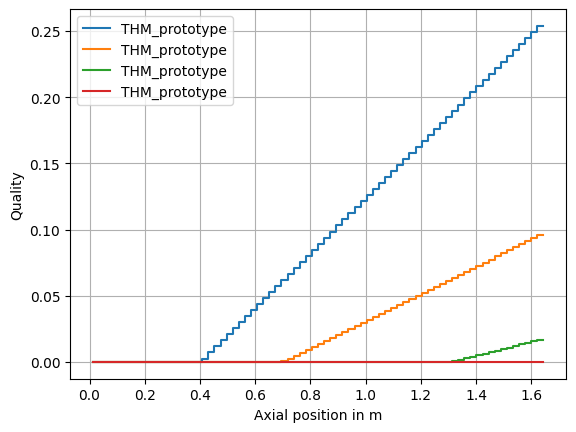

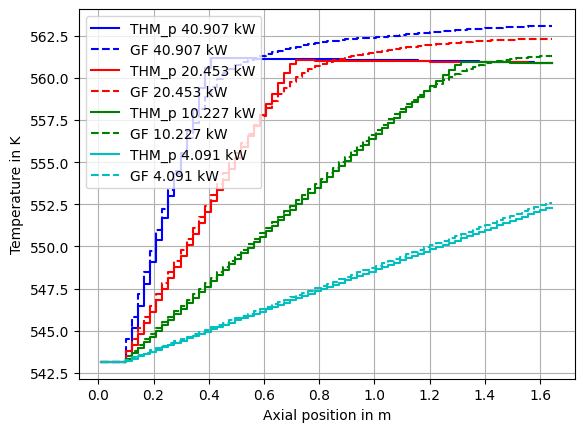

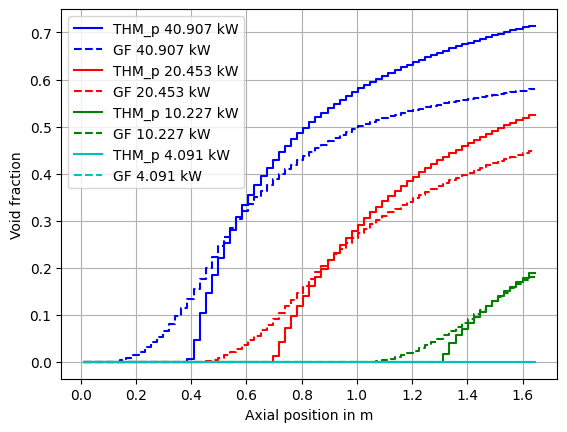

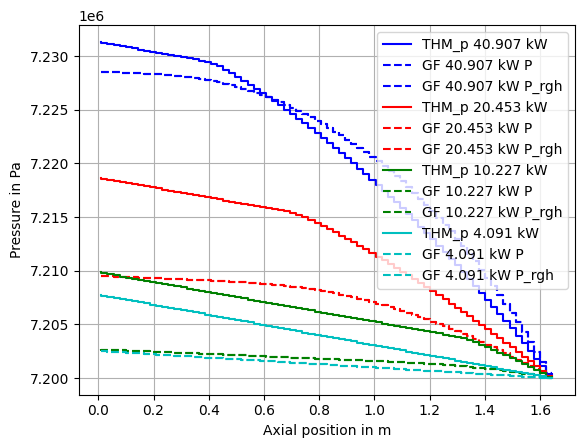

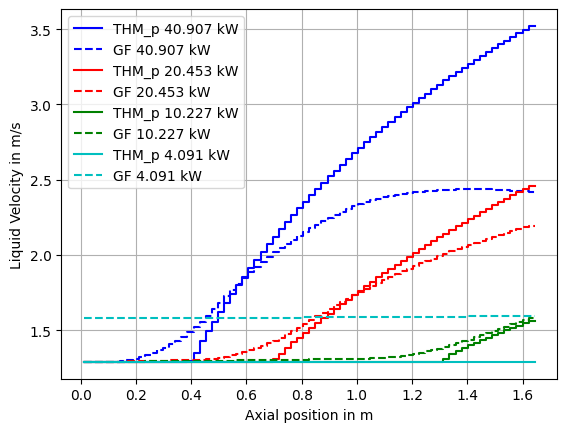

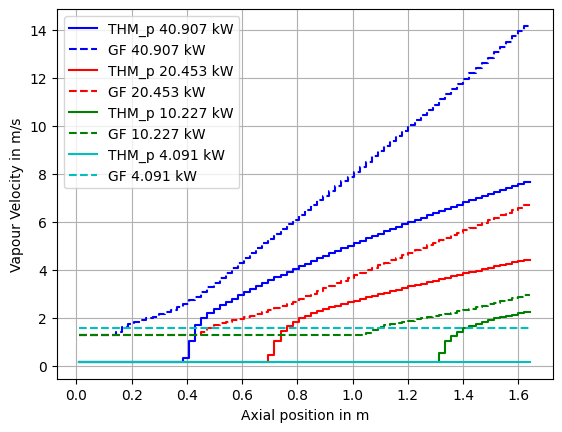

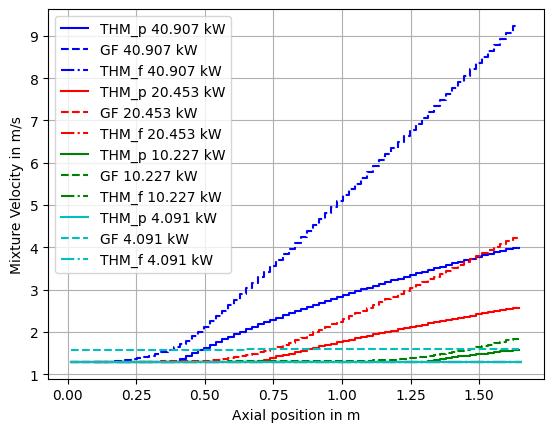

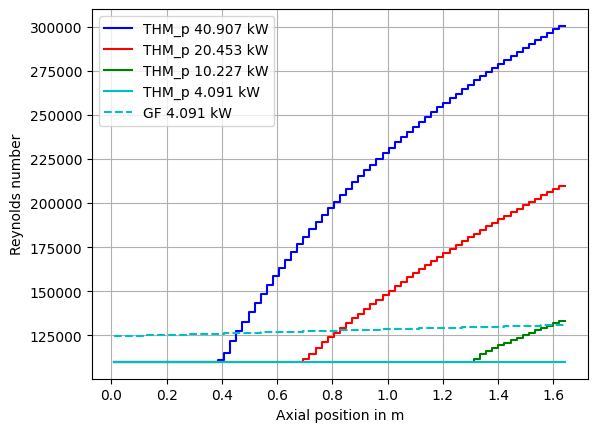

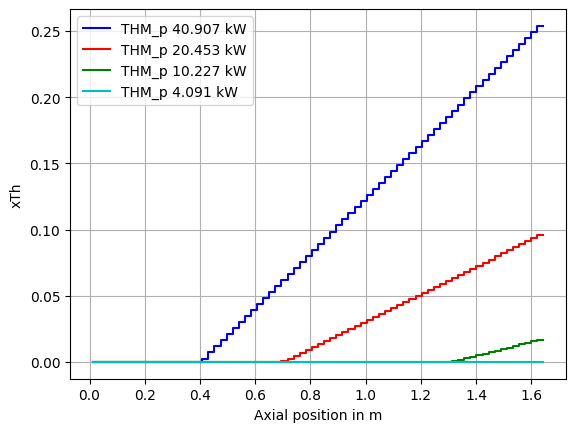

Power: 40.907 kW
Temperature: RMS ERROR 0.23417766764602874 %, MAX ERROR 2.1850780138488517 K, MEAN ERROR 1.1204193466349444 K
Void fraction: RMS ERROR 0.08176029438802193 %, MAX ERROR 0.13415677120705194 %, MEAN ERROR 0.06928229409426682 %
Pressure: RMS ERROR 0.025681936779968804 %, MAX ERROR 2770.0888369167224 Pa, MEAN ERROR 1688.9853233928854 Pa
Velocity: RMS ERROR 38.28046448111911 %, MAX ERROR 5.242823500441425 m/s, MEAN ERROR 1.8970444890910858 m/s


Power: 20.453 kW
Temperature: RMS ERROR 0.1383542343611861 %, MAX ERROR 1.4369297307680426 K, MEAN ERROR 0.6330935907011765 K
Void fraction: RMS ERROR 0.04063264247595784 %, MAX ERROR 0.07868170856778557 %, MEAN ERROR 0.029886305504093234 %
Pressure: RMS ERROR 0.08322288601957567 %, MAX ERROR 9166.345240462571 Pa, MEAN ERROR 5289.7487813885755 Pa
Velocity: RMS ERROR 21.40746699825716 %, MAX ERROR 1.6557855410418973 m/s, MEAN ERROR 0.4810091099131419 m/s


Power: 10.227 kW
Temperature: RMS ERROR 0.041384532167958024 %, MAX ERROR 0.553

In [6]:
title1 = float(400 * fuelRadius**2 * np.pi * height * 1000) #kW
title2 = float(200 * fuelRadius**2 * np.pi * height * 1000) #kW
title3 = float(100 * fuelRadius**2 * np.pi * height * 1000) #kW
title4 = float(40 * fuelRadius**2 * np.pi * height * 1000) #kW
print(f"Power 1: {title1/1000:.6f} MW")
print(f"Power 2: {title2/1000:.6f} MW")
print(f"Power 3: {title3/1000:.6f} MW")
print(f"Power 4: {title4/1000:.6f} MW")
plotter = GFPlotterComp(caseMerge, [rf'C:\Users\cleme\OneDrive\Documents\Poly\BWR\THM_prototype\these\AT10_4', rf'C:\Users\cleme\OneDrive\Documents\Poly\BWR\THM_prototype\these\AT10_2', rf'C:\Users\cleme\OneDrive\Documents\Poly\BWR\THM_prototype\these\AT10_1', rf'C:\Users\cleme\OneDrive\Documents\Poly\BWR\THM_prototype\these\at10_monophasic'], "AT10_compTHMp_THMf_GF", [f"{title1:.3f} kW", f"{title2:.3f} kW", f"{title3:.3f} kW", f"{title4:.3f} kW"], THM_list)
plotter.plotComparison()
ERRORS = plotter.calculateErrors()
for i in range(len(ERRORS)):
    print(f"Power: {plotter.legendList[i]}")
    print(f"Temperature: RMS ERROR {ERRORS[i][0][0]*100} %, MAX ERROR {ERRORS[i][0][1]} K, MEAN ERROR {ERRORS[i][0][2]} K")
    print(f"Void fraction: RMS ERROR {ERRORS[i][1][0]} %, MAX ERROR {ERRORS[i][1][1]} %, MEAN ERROR {ERRORS[i][1][2]} %")
    print(f"Pressure: RMS ERROR {ERRORS[i][2][0]*100} %, MAX ERROR {ERRORS[i][2][1]} Pa, MEAN ERROR {ERRORS[i][2][2]} Pa")
    print(f"Velocity: RMS ERROR {ERRORS[i][3][0]*100} %, MAX ERROR {ERRORS[i][3][1]} m/s, MEAN ERROR {ERRORS[i][3][2]} m/s")
    print("\n")

#plotter = GFPlotterComp(caseMerge, [rf'C:\Users\cleme\OneDrive\Documents\Poly\BWR\THM_prototype\these\AT10_2_blockMesh_grav', rf'C:\Users\cleme\OneDrive\Documents\Poly\BWR\THM_prototype\these\AT10_2_blockMesh'], "AT10_2_blockMesh", [ f"{title2:.2f} MW BM grav ", f"{title2:.2f} MWblockMesh"])
#plotter.plotComparison()

In [7]:
print(caseMerge[0].convection_sol.z_mesh)
print(len(caseMerge[0].convection_sol.z_mesh))

[0.01103333 0.0331     0.05516667 0.07723333 0.0993     0.12136667
 0.14343333 0.1655     0.18756667 0.20963333 0.2317     0.25376667
 0.27583333 0.2979     0.31996667 0.34203333 0.3641     0.38616667
 0.40823333 0.4303     0.45236667 0.47443333 0.4965     0.51856667
 0.54063333 0.5627     0.58476667 0.60683333 0.6289     0.65096667
 0.67303333 0.6951     0.71716667 0.73923333 0.7613     0.78336667
 0.80543333 0.8275     0.84956667 0.87163333 0.8937     0.91576667
 0.93783333 0.9599     0.98196667 1.00403333 1.0261     1.04816667
 1.07023333 1.0923     1.11436667 1.13643333 1.1585     1.18056667
 1.20263333 1.2247     1.24676667 1.26883333 1.2909     1.31296667
 1.33503333 1.3571     1.37916667 1.40123333 1.4233     1.44536667
 1.46743333 1.4895     1.51156667 1.53363333 1.5557     1.57776667
 1.59983333 1.6219     1.64396667]
75


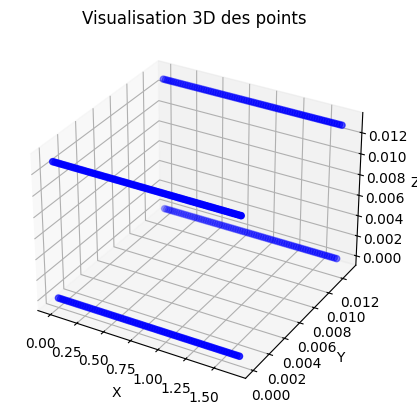

In [8]:
points = [
    (0, 0, 0), (0.02, 0, 0), (0.04, 0, 0), (0.06, 0, 0), (0.08, 0, 0), (0.1, 0, 0),
    (0, 0.01295, 0), (0.02, 0.01295, 0), (0.04, 0.01295, 0), (0.06, 0.01295, 0),
    (0.08, 0.01295, 0), (0.1, 0.01295, 0),
    (0, 0, 0.01295), (0.02, 0, 0.01295), (0.04, 0, 0.01295), (0.06, 0, 0.01295),
    (0.08, 0, 0.01295), (0.1, 0, 0.01295),
    (0, 0.01295, 0.01295), (0.02, 0.01295, 0.01295), (0.04, 0.01295, 0.01295),
    (0.06, 0.01295, 0.01295), (0.08, 0.01295, 0.01295), (0.1, 0.01295, 0.01295),
    (0.1222142857, 0, 0), (0.1444285714, 0, 0), (0.1666428571, 0, 0),
    (0.1888571429, 0, 0), (0.2110714286, 0, 0), (0.2332857143, 0, 0),
    (0.2555, 0, 0), (0.2777142857, 0, 0), (0.2999285714, 0, 0),
    (0.3221428571, 0, 0), (0.3443571429, 0, 0), (0.3665714286, 0, 0),
    (0.3887857143, 0, 0), (0.411, 0, 0), (0.4332142857, 0, 0),
    (0.4554285714, 0, 0), (0.4776428571, 0, 0), (0.4998571429, 0, 0),
    (0.5220714286, 0, 0), (0.5442857143, 0, 0), (0.5665, 0, 0),
    (0.5887142857, 0, 0), (0.6109285714, 0, 0), (0.6331428571, 0, 0),
    (0.6553571429, 0, 0), (0.6775714286, 0, 0), (0.6997857143, 0, 0),
    (0.722, 0, 0), (0.7442142857, 0, 0), (0.7664285714, 0, 0),
    (0.7886428571, 0, 0), (0.8108571429, 0, 0), (0.8330714286, 0, 0),
    (0.8552857143, 0, 0), (0.8775, 0, 0), (0.8997142857, 0, 0),
    (0.9219285714, 0, 0), (0.9441428571, 0, 0), (0.9663571429, 0, 0),
    (0.9885714286, 0, 0), (1.010785714, 0, 0), (1.033, 0, 0),
    (1.055214286, 0, 0), (1.077428571, 0, 0), (1.099642857, 0, 0),
    (1.121857143, 0, 0), (1.144071429, 0, 0), (1.166285714, 0, 0),
    (1.1885, 0, 0), (1.210714286, 0, 0), (1.232928571, 0, 0),
    (1.255142857, 0, 0), (1.277357143, 0, 0), (1.299571429, 0, 0),
    (1.321785714, 0, 0), (1.344, 0, 0), (1.366214286, 0, 0),
    (1.388428571, 0, 0), (1.410642857, 0, 0), (1.432857143, 0, 0),
    (1.455071429, 0, 0), (1.477285714, 0, 0), (1.4995, 0, 0),
    (1.521714286, 0, 0), (1.543928571, 0, 0), (1.566142857, 0, 0),
    (1.588357143, 0, 0), (1.610571429, 0, 0), (1.632785714, 0, 0),
    (1.655, 0, 0), (0.1222142857, 0.01295, 0), (0.1444285714, 0.01295, 0),
    (0.1666428571, 0.01295, 0), (0.1888571429, 0.01295, 0),
    (0.2110714286, 0.01295, 0), (0.2332857143, 0.01295, 0),
    (0.2555, 0.01295, 0), (0.2777142857, 0.01295, 0),
    (0.2999285714, 0.01295, 0), (0.3221428571, 0.01295, 0),
    (0.3443571429, 0.01295, 0), (0.3665714286, 0.01295, 0),
    (0.3887857143, 0.01295, 0), (0.411, 0.01295, 0),
    (0.4332142857, 0.01295, 0), (0.4554285714, 0.01295, 0),
    (0.4776428571, 0.01295, 0), (0.4998571429, 0.01295, 0),
    (0.5220714286, 0.01295, 0), (0.5442857143, 0.01295, 0),
    (0.5665, 0.01295, 0), (0.5887142857, 0.01295, 0),
    (0.6109285714, 0.01295, 0), (0.6331428571, 0.01295, 0),
    (0.6553571429, 0.01295, 0), (0.6775714286, 0.01295, 0),
    (0.6997857143, 0.01295, 0), (0.722, 0.01295, 0),
    (0.7442142857, 0.01295, 0), (0.7664285714, 0.01295, 0),
    (0.7886428571, 0.01295, 0), (0.8108571429, 0.01295, 0),
    (0.8330714286, 0.01295, 0), (0.8552857143, 0.01295, 0),
    (0.8775, 0.01295, 0), (0.8997142857, 0.01295, 0),
    (0.9219285714, 0.01295, 0), (0.9441428571, 0.01295, 0),
    (0.9663571429, 0.01295, 0), (0.9885714286, 0.01295, 0),
    (1.010785714, 0.01295, 0), (1.033, 0.01295, 0),
    (1.055214286, 0.01295, 0),    (1.077428571, 0.01295, 0), (1.099642857, 0.01295, 0),
    (1.121857143, 0.01295, 0), (1.144071429, 0.01295, 0),
    (1.166285714, 0.01295, 0), (1.1885, 0.01295, 0),
    (1.210714286, 0.01295, 0), (1.232928571, 0.01295, 0),
    (1.255142857, 0.01295, 0), (1.277357143, 0.01295, 0),
    (1.299571429, 0.01295, 0), (1.321785714, 0.01295, 0),
    (1.344, 0.01295, 0), (1.366214286, 0.01295, 0),
    (1.388428571, 0.01295, 0), (1.410642857, 0.01295, 0),
    (1.432857143, 0.01295, 0), (1.455071429, 0.01295, 0),
    (1.477285714, 0.01295, 0), (1.4995, 0.01295, 0),
    (1.521714286, 0.01295, 0), (1.543928571, 0.01295, 0),
    (1.566142857, 0.01295, 0), (1.588357143, 0.01295, 0),
    (1.610571429, 0.01295, 0), (1.632785714, 0.01295, 0),
    (1.655, 0.01295, 0),
    (0.1222142857, 0, 0.01295), (0.1444285714, 0, 0.01295),
    (0.1666428571, 0, 0.01295), (0.1888571429, 0, 0.01295),
    (0.2110714286, 0, 0.01295), (0.2332857143, 0, 0.01295),
    (0.2555, 0, 0.01295), (0.2777142857, 0, 0.01295),
    (0.2999285714, 0, 0.01295), (0.3221428571, 0, 0.01295),
    (0.3443571429, 0, 0.01295), (0.3665714286, 0, 0.01295),
    (0.3887857143, 0, 0.01295), (0.411, 0, 0.01295),
    (0.4332142857, 0, 0.01295), (0.4554285714, 0, 0.01295),
    (0.4776428571, 0, 0.01295), (0.4998571429, 0, 0.01295),
    (0.5220714286, 0, 0.01295), (0.5442857143, 0, 0.01295),
    (0.5665, 0, 0.01295), (0.5887142857, 0, 0.01295),
    (0.6109285714, 0, 0.01295), (0.6331428571, 0, 0.01295),
    (0.6553571429, 0, 0.01295), (0.6775714286, 0, 0.01295),
    (0.6997857143, 0, 0.01295), (0.722, 0, 0.01295),
    (0.7442142857, 0, 0.01295), (0.7664285714, 0, 0.01295),
    (0.7886428571, 0, 0.01295), (0.8108571429, 0, 0.01295),
    (0.8330714286, 0, 0.01295), (0.8552857143, 0, 0.01295),
    (0.8775, 0, 0.01295), (0.8997142857, 0, 0.01295),
    (0.9219285714, 0, 0.01295), (0.9441428571, 0, 0.01295),
    (0.9663571429, 0, 0.01295), (0.9885714286, 0, 0.01295),
    (1.010785714, 0, 0.01295), (1.033, 0, 0.01295),
    (1.055214286, 0, 0.01295), (1.077428571, 0, 0.01295),
    (1.099642857, 0, 0.01295), (1.121857143, 0, 0.01295),
    (1.144071429, 0, 0.01295), (1.166285714, 0, 0.01295),
    (1.1885, 0, 0.01295), (1.210714286, 0, 0.01295),
    (1.232928571, 0, 0.01295), (1.255142857, 0, 0.01295),
    (1.277357143, 0, 0.01295), (1.299571429, 0, 0.01295),
    (1.321785714, 0, 0.01295), (1.344, 0, 0.01295),
    (1.366214286, 0, 0.01295), (1.388428571, 0, 0.01295),
    (1.410642857, 0, 0.01295), (1.432857143, 0, 0.01295),
    (1.455071429, 0, 0.01295), (1.477285714, 0, 0.01295),
    (1.4995, 0, 0.01295), (1.521714286, 0, 0.01295),
    (1.543928571, 0, 0.01295), (1.566142857, 0, 0.01295),
    (1.588357143, 0, 0.01295), (1.610571429, 0, 0.01295),
    (1.632785714, 0, 0.01295), (1.655, 0, 0.01295),
    (0.1222142857, 0.01295, 0.01295), (0.1444285714, 0.01295, 0.01295),
    (0.1666428571, 0.01295, 0.01295), (0.1888571429, 0.01295, 0.01295),
    (0.2110714286, 0.01295, 0.01295), (0.2332857143, 0.01295, 0.01295),
    (0.2555, 0.01295, 0.01295), (0.2777142857, 0.01295, 0.01295),
    (0.2999285714, 0.01295, 0.01295), (0.3221428571, 0.01295, 0.01295),
    (0.3443571429, 0.01295, 0.01295), (0.3665714286, 0.01295, 0.01295),
    (0.3887857143, 0.01295, 0.01295), (0.411, 0.01295, 0.01295),
    (0.4332142857, 0.01295, 0.01295), (0.4554285714, 0.01295, 0.01295),
    (0.4776428571, 0.01295, 0.01295), (0.4998571429, 0.01295, 0.01295),
    (0.5220714286, 0.01295, 0.01295), (0.5442857143, 0.01295, 0.01295),
    (0.5665, 0.01295, 0.01295),     (0.5887142857, 0.01295, 0.01295), (0.6109285714, 0.01295, 0.01295),
    (0.6331428571, 0.01295, 0.01295), (0.6553571429, 0.01295, 0.01295),
    (0.6775714286, 0.01295, 0.01295), (0.6997857143, 0.01295, 0.01295),
    (0.722, 0.01295, 0.01295), (0.7442142857, 0.01295, 0.01295),
    (0.7664285714, 0.01295, 0.01295), (0.7886428571, 0.01295, 0.01295),
    (0.8108571429, 0.01295, 0.01295), (0.8330714286, 0.01295, 0.01295),
    (0.8552857143, 0.01295, 0.01295), (0.8775, 0.01295, 0.01295),
    (0.8997142857, 0.01295, 0.01295), (0.9219285714, 0.01295, 0.01295),
    (0.9441428571, 0.01295, 0.01295), (0.9663571429, 0.01295, 0.01295),
    (0.9885714286, 0.01295, 0.01295), (1.010785714, 0.01295, 0.01295),
    (1.033, 0.01295, 0.01295), (1.055214286, 0.01295, 0.01295),
    (1.077428571, 0.01295, 0.01295), (1.099642857, 0.01295, 0.01295),
    (1.121857143, 0.01295, 0.01295), (1.144071429, 0.01295, 0.01295),
    (1.166285714, 0.01295, 0.01295), (1.1885, 0.01295, 0.01295),
    (1.210714286, 0.01295, 0.01295), (1.232928571, 0.01295, 0.01295),
    (1.255142857, 0.01295, 0.01295), (1.277357143, 0.01295, 0.01295),
    (1.299571429, 0.01295, 0.01295), (1.321785714, 0.01295, 0.01295),
    (1.344, 0.01295, 0.01295), (1.366214286, 0.01295, 0.01295),
    (1.388428571, 0.01295, 0.01295), (1.410642857, 0.01295, 0.01295),
    (1.432857143, 0.01295, 0.01295), (1.455071429, 0.01295, 0.01295),
    (1.477285714, 0.01295, 0.01295), (1.4995, 0.01295, 0.01295),
    (1.521714286, 0.01295, 0.01295), (1.543928571, 0.01295, 0.01295),
    (1.566142857, 0.01295, 0.01295), (1.588357143, 0.01295, 0.01295),
    (1.610571429, 0.01295, 0.01295), (1.632785714, 0.01295, 0.01295),
    (1.655, 0.01295, 0.01295)
]
# Séparer les coordonnées x, y et z
x_coords, y_coords, z_coords = zip(*points)

# Création de la figure 3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Ajouter les points dans le graphique
ax.scatter(x_coords, y_coords, z_coords, c='b', marker='o')

# Labels des axes
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# Titre
plt.title('Visualisation 3D des points')

# Afficher le graphique
plt.show()